# 04 - Valores atípicos y consistencia cuantitativa

**Objetivo.** Detectar valores imposibles, inconsistentes o extremos en variables cuantitativas relevantes. En esta etapa no se eliminan automáticamente outliers plausibles: se crean flags para sostener decisiones posteriores.

En real estate, un valor extremo puede ser válido. Por eso se distinguen valores imposibles de extremos plausibles.

## Criterio metodológico de outliers

Los valores extremos no se eliminan automáticamente. En mercado inmobiliario pueden representar errores de carga, pero también propiedades premium, superficies atípicas o submercados reales. Por eso esta etapa prioriza marcar outliers, visualizar distribuciones y dejar flags reutilizables. La exclusión, winsorización o transformación logarítmica se decide luego según el KPI o modelo puntual.


In [1]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
EXTERNAL_DIR = REPO_ROOT / 'Fuentes_de_enriquecimiento'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

REPO_ROOT: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026
RAW_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\raw
PROCESSED_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\processed


## Carga de datasets con flags de nulos

Si todavía no existen, se cargan los datasets preprocesados del notebook 02.

In [2]:
base_sources = {
    'df_preprocesado_meli_alq': PROCESSED_DIR / 'df_preprocesado_meli_alq_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_alq_temp': PROCESSED_DIR / 'df_preprocesado_meli_alq_temp_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_vtas': PROCESSED_DIR / 'df_preprocesado_meli_vtas_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_vtas': PROCESSED_DIR / 'df_preprocesado_argenprop_vtas_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_alq': PROCESSED_DIR / 'df_preprocesado_argenprop_alq_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_vtas': PROCESSED_DIR / 'df_preprocesado_zonaprop_vtas_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_alq': PROCESSED_DIR / 'df_preprocesado_zonaprop_alq_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_airbnb_temp': PROCESSED_DIR / 'df_preprocesado_airbnb_temp_post_ajustes_con_flags_nulos_v1.csv',
}

fallback_sources = {
    'df_preprocesado_meli_alq': PROCESSED_DIR / 'df_preprocesado_meli_alq_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_alq_temp': PROCESSED_DIR / 'df_preprocesado_meli_alq_temp_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_vtas': PROCESSED_DIR / 'df_preprocesado_meli_vtas_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_vtas': PROCESSED_DIR / 'df_preprocesado_argenprop_vtas_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_alq': PROCESSED_DIR / 'df_preprocesado_argenprop_alq_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_vtas': PROCESSED_DIR / 'df_preprocesado_zonaprop_vtas_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_alq': PROCESSED_DIR / 'df_preprocesado_zonaprop_alq_con_flags_nulos_v1.csv',
    'df_preprocesado_airbnb_temp': PROCESSED_DIR / 'df_preprocesado_airbnb_temp_con_flags_nulos_v1.csv',
}

preprocesados_outliers = {}

for name, path in base_sources.items():
    source = path if path.exists() else fallback_sources[name]

    if not source.exists():
        raise FileNotFoundError(f'Falta {source}. Ejecutar notebooks anteriores.')

    preprocesados_outliers[name] = pd.read_csv(source, low_memory=False)
    print(name, preprocesados_outliers[name].shape, 'desde', source.name)

df_preprocesado_meli_alq (9877, 79) desde df_preprocesado_meli_alq_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_meli_alq_temp (4494, 81) desde df_preprocesado_meli_alq_temp_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_meli_vtas (42778, 82) desde df_preprocesado_meli_vtas_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_argenprop_vtas (82, 60) desde df_preprocesado_argenprop_vtas_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_argenprop_alq (80, 59) desde df_preprocesado_argenprop_alq_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_zonaprop_vtas (485, 62) desde df_preprocesado_zonaprop_vtas_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_zonaprop_alq (495, 56) desde df_preprocesado_zonaprop_alq_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_airbnb_temp (9596, 85) desde df_preprocesado_airbnb_temp_post_ajustes_con_flags_nulos_v1.csv


## Consolidación de Bases

Para facilitar el análisis de frecuencias en celdas posteriores, se crea una base consolidada temporal.

In [3]:
# ============================================================
# CREAR BASE TEMPORAL PARA ANÁLISIS DE OUTLIERS
# TODAS LAS BASES
# ============================================================

# Los datasets fueron cargados en el diccionario preprocesados_outliers.
# Se evita depender de variables globales sueltas para mantener el notebook ejecutable desde cero.
datasets_outliers = preprocesados_outliers.copy()


dfs_temporales = []

for nombre, df_base in datasets_outliers.items():

    temp = df_base.copy()

    # Identificar de qué base proviene cada publicación
    temp['dataset_preprocesado'] = nombre

    dfs_temporales.append(temp)


# Unir las 8 bases solamente para análisis exploratorio de outliers
df_analisis_outliers = pd.concat(
    dfs_temporales,
    ignore_index=True,
    sort=False
)


print(
    "Cantidad total de publicaciones:",
    len(df_analisis_outliers)
)

print("\nCantidad por base:")
display(
    df_analisis_outliers['dataset_preprocesado']
    .value_counts()
    .to_frame('publicaciones')
)


Cantidad total de publicaciones: 67887

Cantidad por base:


,publicaciones
dataset_preprocesado,
df_preprocesado_meli_vtas,42778
df_preprocesado_meli_alq,9877
df_preprocesado_airbnb_temp,9596
df_preprocesado_meli_alq_temp,4494
df_preprocesado_zonaprop_alq,495
df_preprocesado_zonaprop_vtas,485
df_preprocesado_argenprop_vtas,82
df_preprocesado_argenprop_alq,80


## Funciones de detección de outliers

In [4]:
VARIABLES_OUTLIERS = ['precio', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref', 'altura', 'latitud', 'longitud', 'rating', 'reviews']

CABA_LAT_MIN, CABA_LAT_MAX = -34.75, -34.50
CABA_LON_MIN, CABA_LON_MAX = -58.55, -58.30


def add_outlier_flags(df, dataset_name, p_low=0.01, p_high=0.99):
    out = df.copy()
    rows = []
    group_cols = [c for c in ['fuente_norm', 'tipo_operacion_norm', 'moneda_norm'] if c in out.columns]

    for col in VARIABLES_OUTLIERS:
        if col not in out.columns or not pd.api.types.is_numeric_dtype(out[col]):
            continue
        s = out[col]

        invalid_flag = f'{col}_valor_invalido_flag'
        if col in ['precio', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref']:
            out[invalid_flag] = (s.notna() & (s <= 0)).astype('int8')
        elif col == 'rating':
            out[invalid_flag] = (s.notna() & ((s < 0) | (s > 5))).astype('int8')
        elif col == 'latitud':
            out[invalid_flag] = (s.notna() & ((s < CABA_LAT_MIN) | (s > CABA_LAT_MAX))).astype('int8')
        elif col == 'longitud':
            out[invalid_flag] = (s.notna() & ((s < CABA_LON_MIN) | (s > CABA_LON_MAX))).astype('int8')
        else:
            out[invalid_flag] = 0

        valid = out[out[invalid_flag].eq(0) & out[col].notna()].copy()
        outlier_flag = f'{col}_outlier_p01_p99_flag'
        out[outlier_flag] = 0

        if valid.empty or valid[col].nunique(dropna=True) <= 1:
            continue

        if group_cols:
            qs = valid.groupby(group_cols)[col].quantile([p_low, p_high]).unstack()
            qs.columns = ['p01', 'p99']
            valid = valid.join(qs, on=group_cols)
            mask_outlier = (valid[col] < valid['p01']) | (valid[col] > valid['p99'])
            out.loc[valid.index, outlier_flag] = mask_outlier.astype('int8')
        else:
            q_low, q_high = valid[col].quantile([p_low, p_high])
            mask_outlier = (valid[col] < q_low) | (valid[col] > q_high)
            out.loc[valid.index, outlier_flag] = mask_outlier.astype('int8')

        rows.append({
            'dataset': dataset_name,
            'variable': col,
            'n_no_nulos': int(s.notna().sum()),
            'n_invalidos': int(out[invalid_flag].sum()),
            'n_outliers_p01_p99': int(out[outlier_flag].sum()),
            'pct_invalidos': round(out[invalid_flag].mean() * 100, 2),
            'pct_outliers_p01_p99': round(out[outlier_flag].mean() * 100, 2),
        })

    return out, pd.DataFrame(rows)

## Aplicación por dataset

In [5]:
preprocesados_con_outliers = {}
reportes_outliers = []
for name, df in preprocesados_outliers.items():
    df_out, reporte = add_outlier_flags(df, name)
    preprocesados_con_outliers[name] = df_out
    if not reporte.empty:
        reportes_outliers.append(reporte)
    print(name, df_out.shape, 'flags outliers:', sum(c.endswith('_flag') for c in df_out.columns))

reporte_outliers = pd.concat(reportes_outliers, ignore_index=True) if reportes_outliers else pd.DataFrame()
display(reporte_outliers)
reporte_outliers.to_csv(REPORTS_DIR / 'reporte_outliers_v1.csv', index=False)

df_preprocesado_meli_alq (9877, 93) flags outliers: 14
df_preprocesado_meli_alq_temp (4494, 95) flags outliers: 14
df_preprocesado_meli_vtas (42778, 96) flags outliers: 14
df_preprocesado_argenprop_vtas (82, 74) flags outliers: 14
df_preprocesado_argenprop_alq (80, 73) flags outliers: 14
df_preprocesado_zonaprop_vtas (485, 74) flags outliers: 12
df_preprocesado_zonaprop_alq (495, 68) flags outliers: 12
df_preprocesado_airbnb_temp (9596, 105) flags outliers: 20


,dataset,variable,n_no_nulos,n_invalidos,n_outliers_p01_p99,pct_invalidos,pct_outliers_p01_p99
0,df_preprocesado_meli_alq,precio,9877,0,173,0.00,1.75
1,df_preprocesado_meli_alq,precio_m2_ref,9835,0,198,0.00,2.00
2,df_preprocesado_meli_alq,superficie_ref_m2,9835,0,180,0.00,1.82
3,df_preprocesado_meli_alq,ambientes_ref,9603,0,79,0.00,0.80
4,df_preprocesado_meli_alq,dormitorios_ref,38,0,0,0.00,0.00
5,df_preprocesado_meli_alq,banios_ref,9689,0,19,0.00,0.19
6,df_preprocesado_meli_alq,altura,8473,0,161,0.00,1.63
7,df_preprocesado_meli_alq_temp,precio,4494,0,89,0.00,1.98
8,df_preprocesado_meli_alq_temp,precio_m2_ref,4475,0,90,0.00,2.00
9,df_preprocesado_meli_alq_temp,superficie_ref_m2,4475,0,76,0.00,1.69


Del análisis P01-P99, llama la atención que el 16,93% de los datos de dormitorios_ref de airbnb_temp sean inválidos. Haciendo el siguiente análisis y observando la tabla de frecuencias, determinamos que los inválidos no tienen un valor absurdo de dormitorios, sino que tienen un valor aceptable para estancias o casas grandes (siendo 18 la cantidad máxima)

In [6]:
# ============================================================
# ANALIZAR DORMITORIOS REF
# ============================================================

print("Cantidad de valores no nulos:")
print(
     df['dormitorios_ref'].notna().sum()
)

print("\nCantidad de valores nulos:")
print(
    df['dormitorios_ref'].isna().sum()
)

print("\nFrecuencia de cada valor:")
print(
    df['dormitorios_ref']
    .value_counts()
    .sort_index()
)

Cantidad de valores no nulos:
9594

Cantidad de valores nulos:
2

Frecuencia de cada valor:
dormitorios_ref
0.0     1625
1.0     6470
2.0     1166
3.0      238
4.0       52
5.0       15
6.0        7
7.0        4
8.0        2
9.0        1
10.0       4
11.0       1
12.0       3
14.0       2
15.0       1
16.0       2
18.0       1
Name: count, dtype: int64


Se realiza un análisis similar con los baños en airbnb_temp, concluyendo nuevamente que, aunque destaca, puede existir una vivienda con entre 10 y 17 baños, y no se trata de un valor absurdo

In [7]:
# ============================================================
# ANALIZAR BANIOS REF
# ============================================================

# Revisión puntual sobre la base temporal consolidada del notebook.
# Sirve para interpretar si los extremos de baños son errores o casos plausibles.
if 'banios_ref' not in df_analisis_outliers.columns:
    print('La columna banios_ref no está disponible en la base de análisis.')
else:
    print("Cantidad de valores no nulos:")
    print(df_analisis_outliers['banios_ref'].notna().sum())

    print("\nCantidad de valores nulos:")
    print(df_analisis_outliers['banios_ref'].isna().sum())

    print("\nFrecuencia de cada valor:")
    display(
        df_analisis_outliers['banios_ref']
        .value_counts(dropna=False)
        .sort_index()
        .to_frame('conteo')
    )


Cantidad de valores no nulos:
66517

Cantidad de valores nulos:
1370

Frecuencia de cada valor:


,conteo
banios_ref,
0.0,43
1.0,50331
2.0,12275
3.0,2844
4.0,767
5.0,176
6.0,28
7.0,14
8.0,6


## Valores Extremos con IQR

Se buscan valores extremos con IQR, pero comparando propiedades dentro de grupos similares, para complementar el P01–P99.

In [8]:
# ============================================================
# OUTLIERS - MÉTODO IQR
# APLICADO A LAS 8 BASES
# ============================================================

VARIABLES_IQR = [
    'precio',
    'precio_m2_ref',
    'precio_noche_estimado',
    'precio_mensual_estimado',
    'superficie_ref_m2',
    'ambientes_ref',
    'dormitorios_ref',
    'banios_ref',
    'altura'
]


def add_iqr_flags(df, dataset_name):

    """
    Detecta valores atípicos mediante IQR.

    El cálculo se realiza dentro de cada dataset y,
    cuando es posible, separando por fuente, operación
    y moneda.
    """

    out = df.copy()

    reporte = []

    # Grupos comparables
    group_cols = [
        c for c in [
            'fuente_norm',
            'tipo_operacion_norm',
            'moneda_norm'
        ]
        if c in out.columns
    ]

    for variable in VARIABLES_IQR:

        if variable not in out.columns:
            continue

        # ----------------------------------------------------
        # Convertir a numérico
        # ----------------------------------------------------

        valores = pd.to_numeric(
            out[variable],
            errors='coerce'
        )

        # ----------------------------------------------------
        # Valores válidos
        # ----------------------------------------------------

        validos = valores.notna()

        # Variables que no pueden ser <= 0
        if variable in [
            'precio',
            'precio_m2_ref',
            'precio_noche_estimado',
            'precio_mensual_estimado',
            'superficie_ref_m2',
            'ambientes_ref',
            'dormitorios_ref',
            'banios_ref'
        ]:
            validos &= valores > 0

        flag_col = (
            f'{variable}_outlier_iqr_flag'
        )

        out[flag_col] = 0

        # ----------------------------------------------------
        # Calcular IQR por grupo
        # ----------------------------------------------------

        if group_cols:

            grupos = out.groupby(
                group_cols,
                dropna=False
            ).groups

        else:

            grupos = {
                'todos': out.index
            }

        # ----------------------------------------------------
        # Procesar cada grupo
        # ----------------------------------------------------

        for _, indices in grupos.items():

            muestra = valores.loc[indices][
                validos.loc[indices]
            ]

            # Grupos demasiado pequeños
            if len(muestra) < 4:
                continue

            q1 = muestra.quantile(0.25)
            q3 = muestra.quantile(0.75)

            iqr = q3 - q1

            limite_inferior = (
                q1 - 1.5 * iqr
            )

            limite_superior = (
                q3 + 1.5 * iqr
            )

            mascara = (
                validos.loc[indices]
                &
                (
                    (valores.loc[indices] < limite_inferior)
                    |
                    (valores.loc[indices] > limite_superior)
                )
            )

            out.loc[
                mascara.index[mascara],
                flag_col
            ] = 1

        # ----------------------------------------------------
        # Reporte
        # ----------------------------------------------------

        n_validos = int(
            validos.sum()
        )

        n_outliers = int(
            out[flag_col].sum()
        )

        reporte.append({
            'dataset': dataset_name,
            'variable': variable,
            'n_validos': n_validos,
            'n_outliers_iqr': n_outliers,
            'pct_outliers_iqr': (
                round(
                    100 * n_outliers / n_validos,
                    2
                )
                if n_validos > 0
                else np.nan
            )
        })

    return out, pd.DataFrame(reporte)

## Aplicar a las bases outliers por IQR

df_preprocesado_meli_alq (9877, 100) → IQR aplicado
df_preprocesado_meli_alq_temp (4494, 102) → IQR aplicado
df_preprocesado_meli_vtas (42778, 103) → IQR aplicado
df_preprocesado_argenprop_vtas (82, 81) → IQR aplicado
df_preprocesado_argenprop_alq (80, 80) → IQR aplicado
df_preprocesado_zonaprop_vtas (485, 80) → IQR aplicado
df_preprocesado_zonaprop_alq (495, 74) → IQR aplicado
df_preprocesado_airbnb_temp (9596, 111) → IQR aplicado


,dataset,variable,n_validos,n_outliers_iqr,pct_outliers_iqr
0,df_preprocesado_meli_alq,precio,9877,782,7.92
1,df_preprocesado_meli_alq,precio_m2_ref,9835,322,3.27
2,df_preprocesado_meli_alq,superficie_ref_m2,9835,706,7.18
3,df_preprocesado_meli_alq,ambientes_ref,9603,206,2.15
4,df_preprocesado_meli_alq,dormitorios_ref,38,2,5.26
5,df_preprocesado_meli_alq,banios_ref,9689,865,8.93
6,df_preprocesado_meli_alq,altura,8473,163,1.92
7,df_preprocesado_meli_alq_temp,precio,4494,513,11.42
8,df_preprocesado_meli_alq_temp,precio_m2_ref,4475,492,10.99
9,df_preprocesado_meli_alq_temp,superficie_ref_m2,4475,284,6.35


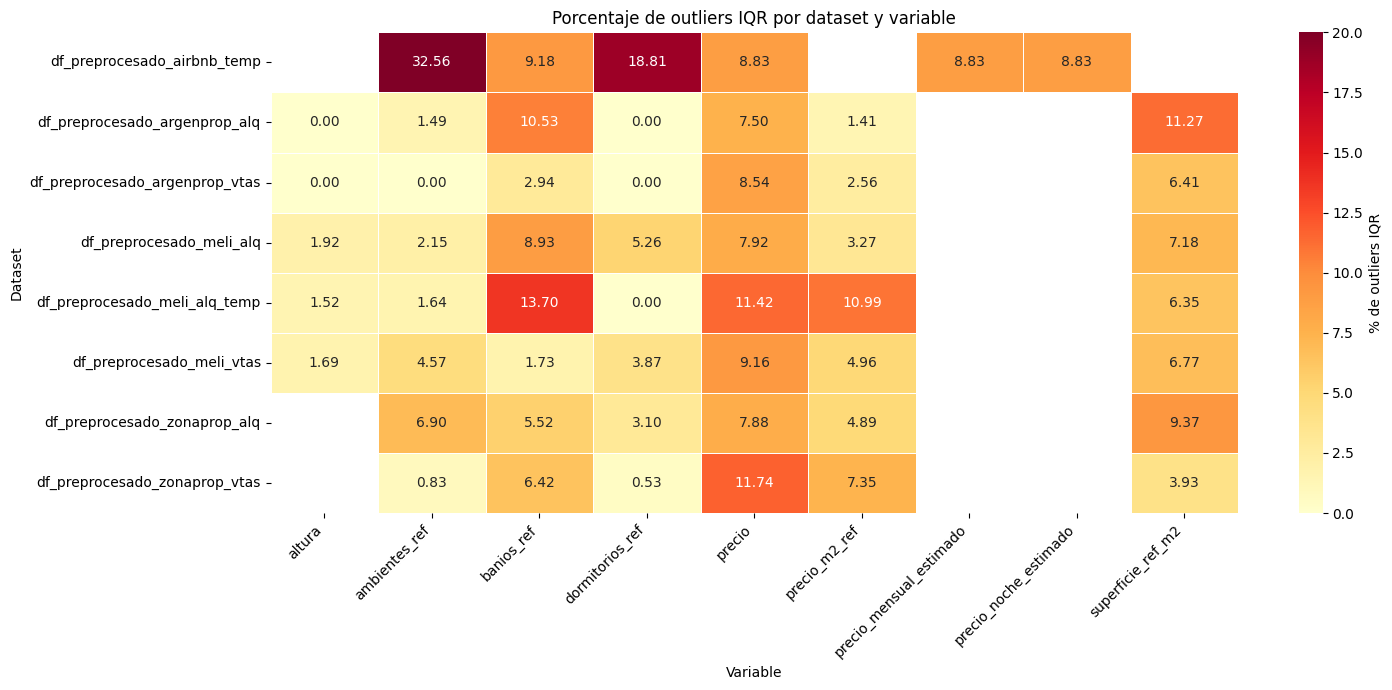

In [9]:
# ============================================================
# APLICAR IQR A LAS 8 BASES
# ============================================================

preprocesados_con_iqr = {}

reportes_iqr = []

for nombre, df in preprocesados_con_outliers.items():

    df_iqr, reporte_iqr = add_iqr_flags(
        df,
        dataset_name=nombre
    )

    preprocesados_con_iqr[nombre] = df_iqr

    if not reporte_iqr.empty:
        reportes_iqr.append(
            reporte_iqr
        )

    print(
        nombre,
        df_iqr.shape,
        '→ IQR aplicado'
    )


# ------------------------------------------------------------
# Consolidar reporte
# ------------------------------------------------------------

reporte_iqr_todas = (
    pd.concat(reportes_iqr, ignore_index=True)
    if reportes_iqr
    else pd.DataFrame(columns=['dataset', 'variable', 'n_validos', 'q1', 'q3', 'iqr', 'limite_inferior', 'limite_superior', 'n_outliers_iqr', 'pct_outliers_iqr'])
)

display(
    reporte_iqr_todas
)


# ------------------------------------------------------------
# Guardar reporte
# ------------------------------------------------------------

reporte_iqr_todas.to_csv(
    REPORTS_DIR /
    'reporte_outliers_iqr_todas_las_bases.csv',
    index=False
)

# ============================================================
# HEATMAP - % DE OUTLIERS IQR POR DATASET Y VARIABLE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Pasar de formato largo a matriz
matriz_iqr = reporte_iqr_todas.pivot(
    index='dataset',
    columns='variable',
    values='pct_outliers_iqr'
)

# Ordenar datasets
matriz_iqr = matriz_iqr.sort_index()

# Crear gráfico

plt.figure(figsize=(15, 7))

sns.heatmap(
    matriz_iqr,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0,
    vmax=20,
    cbar_kws={'label': '% de outliers IQR'}
)

plt.title('Porcentaje de outliers IQR por dataset y variable')
plt.xlabel('Variable')
plt.ylabel('Dataset')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


## Boxplots - Visualización de Outliers por IQR

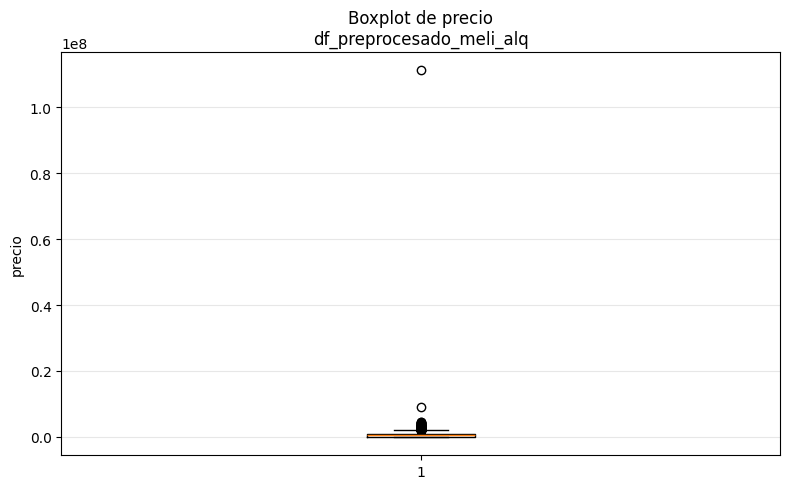

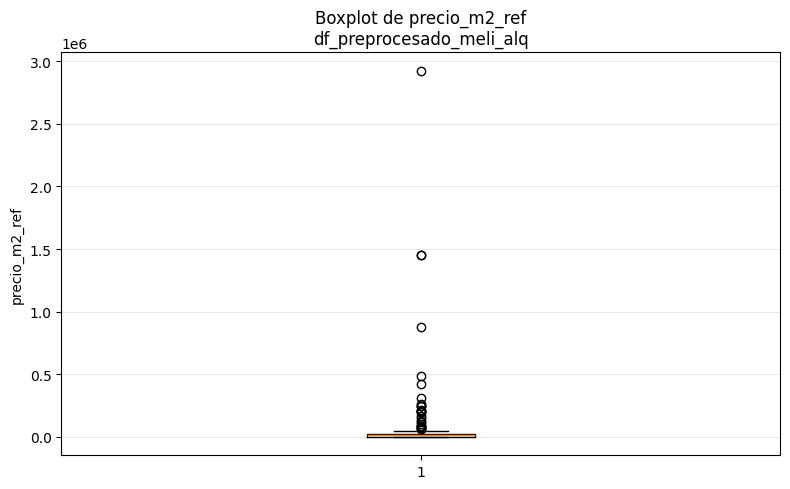

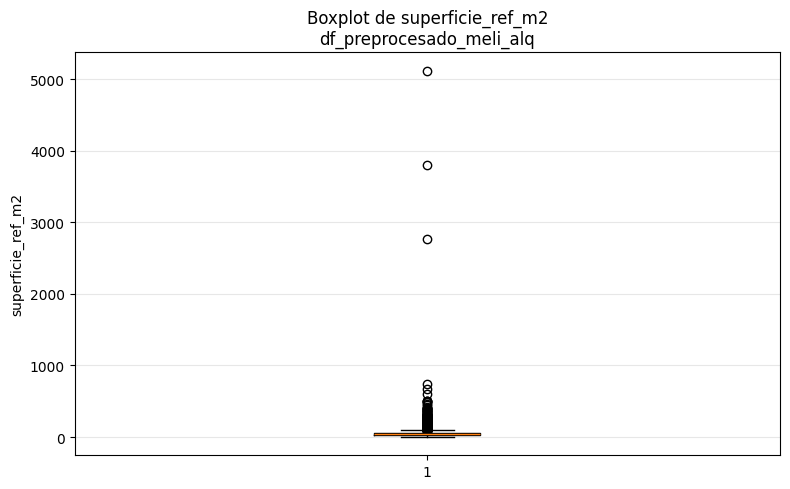

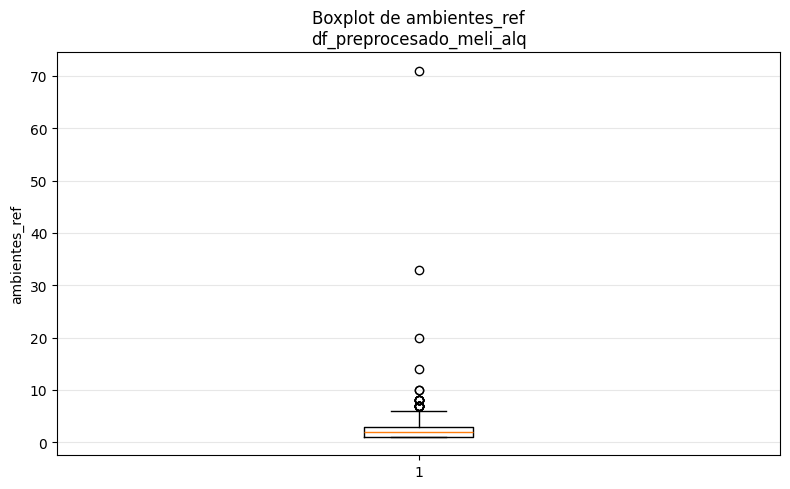

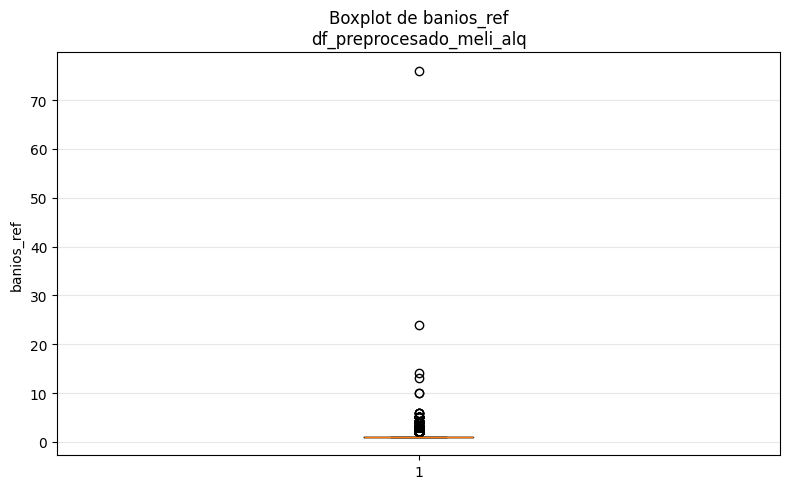

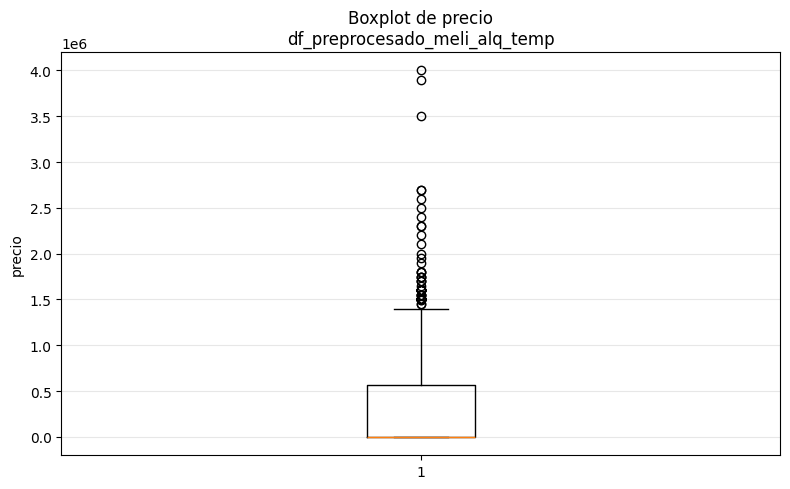

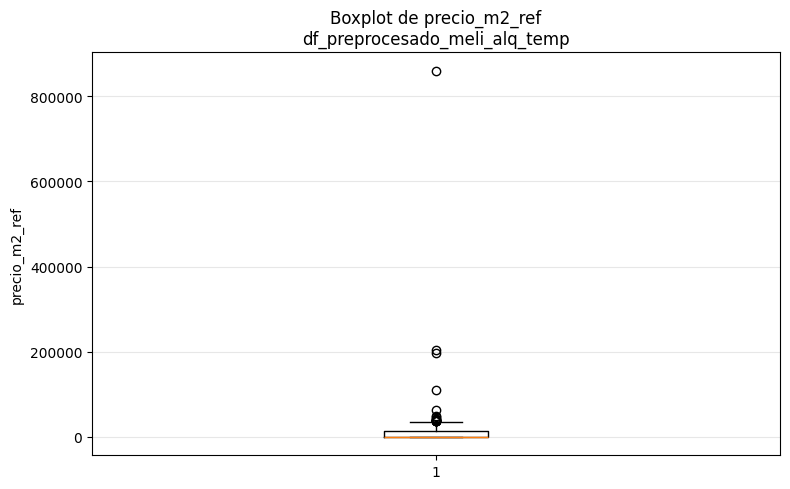

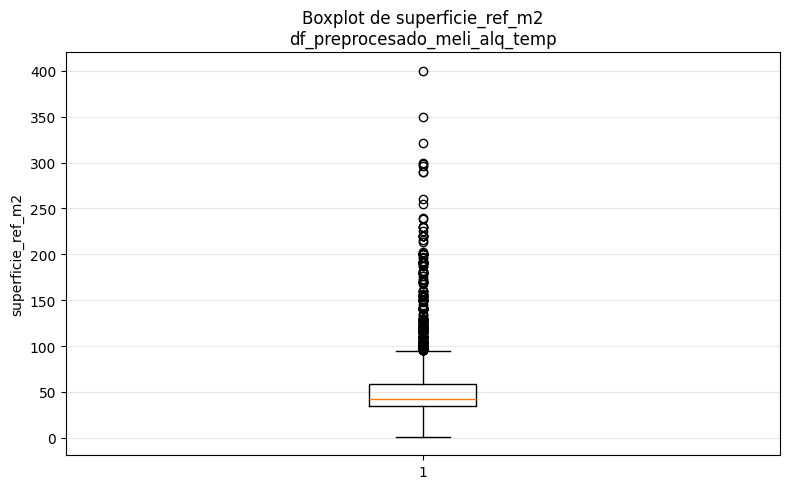

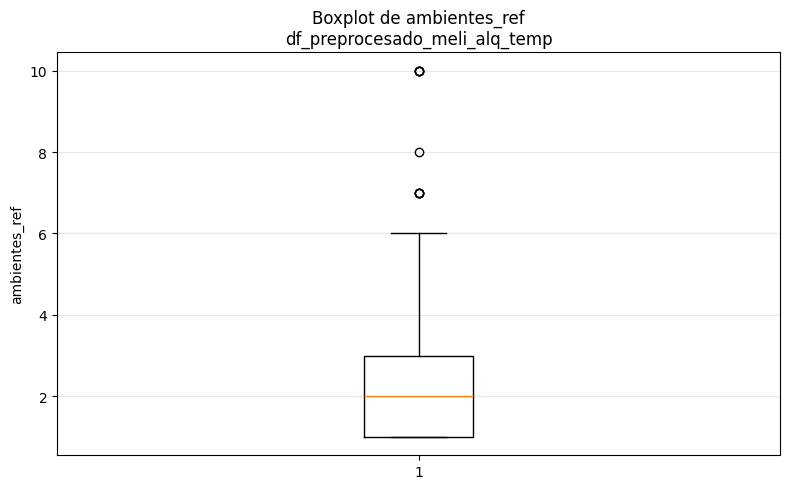

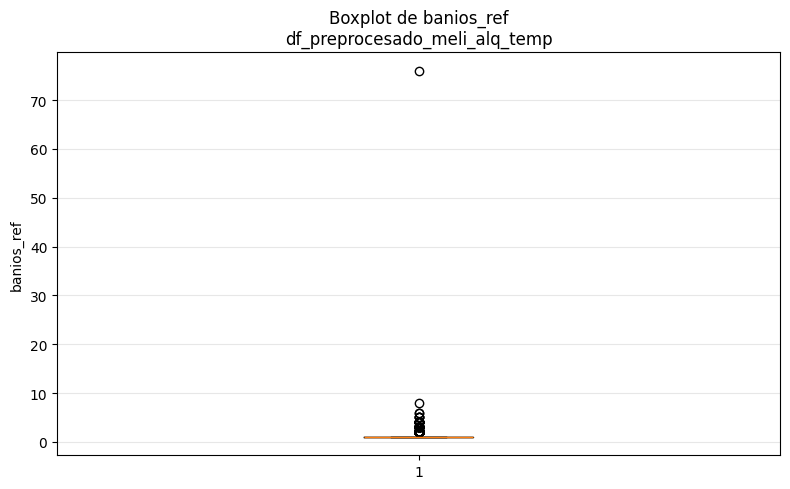

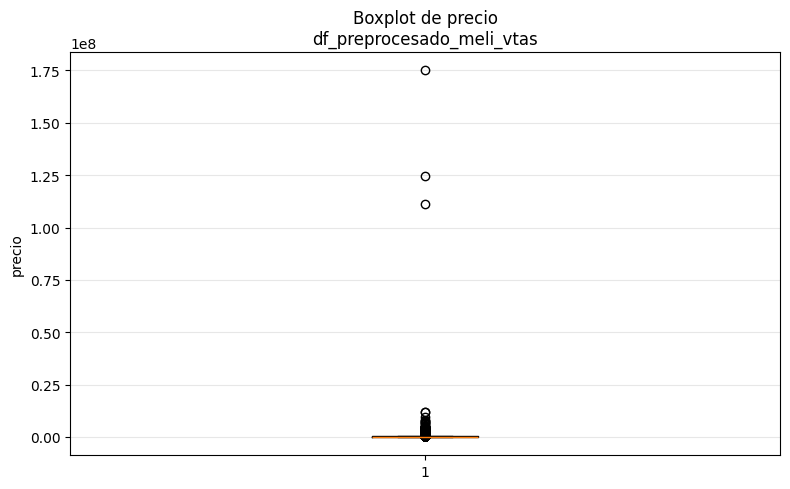

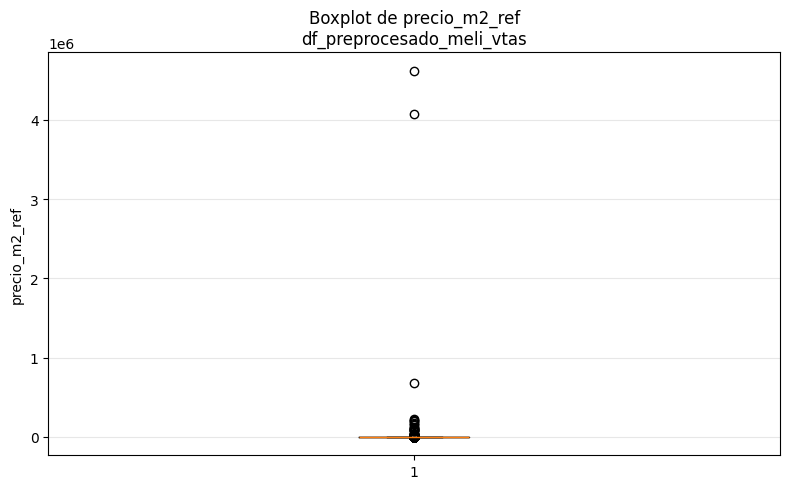

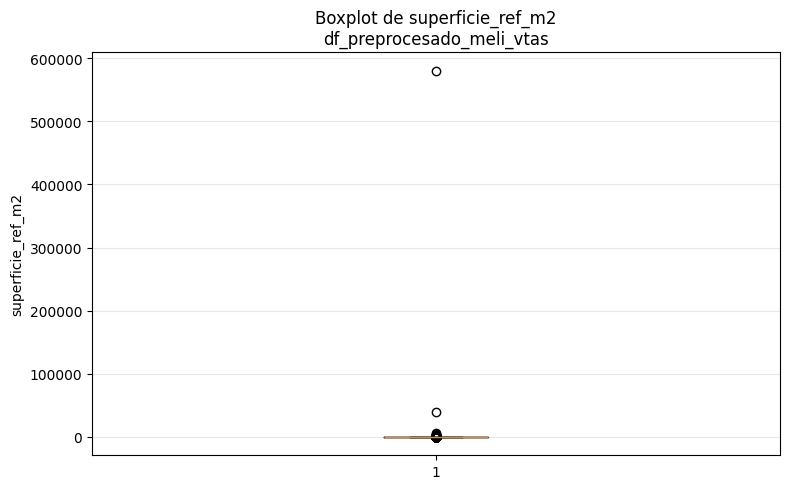

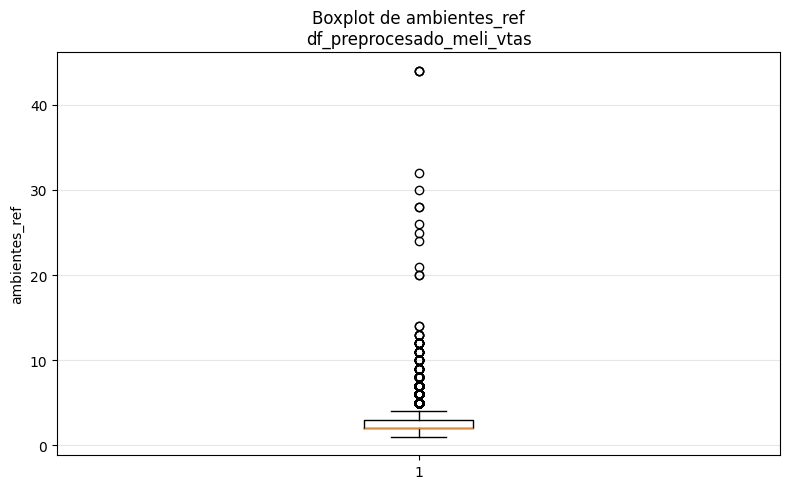

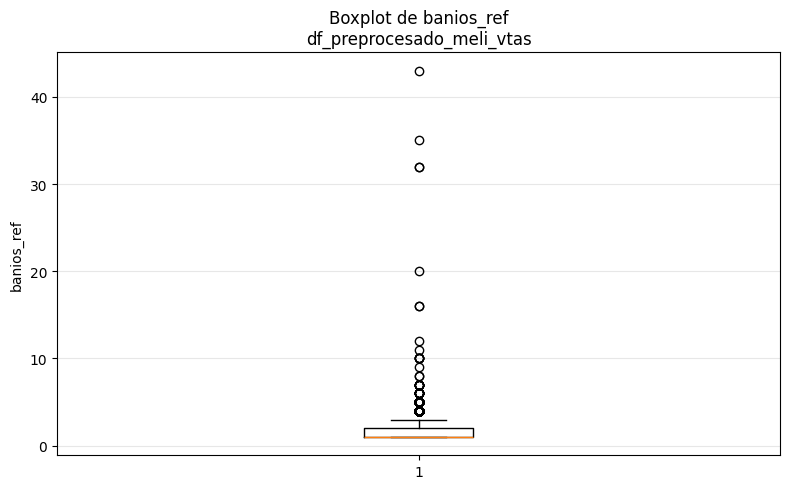

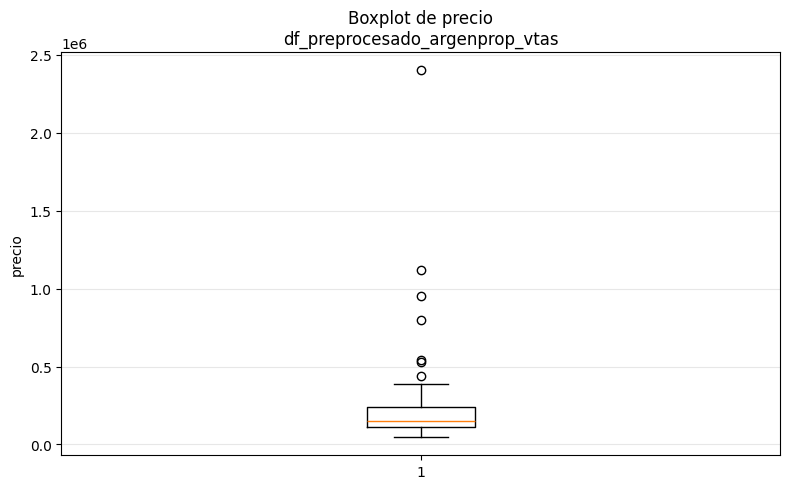

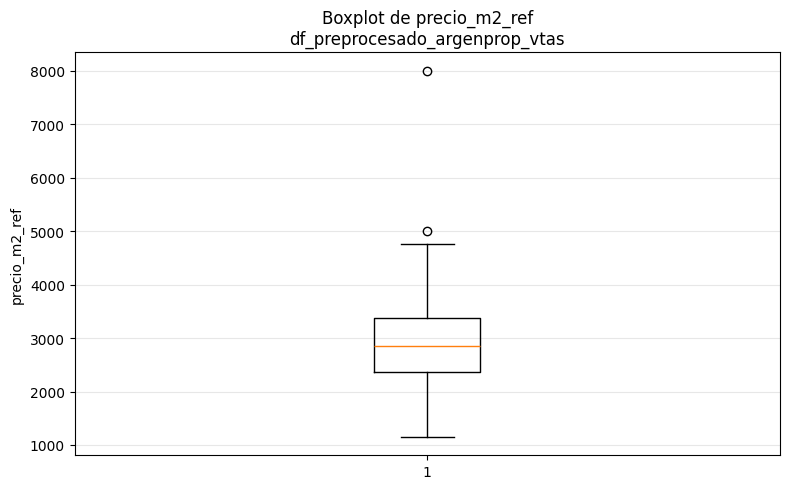

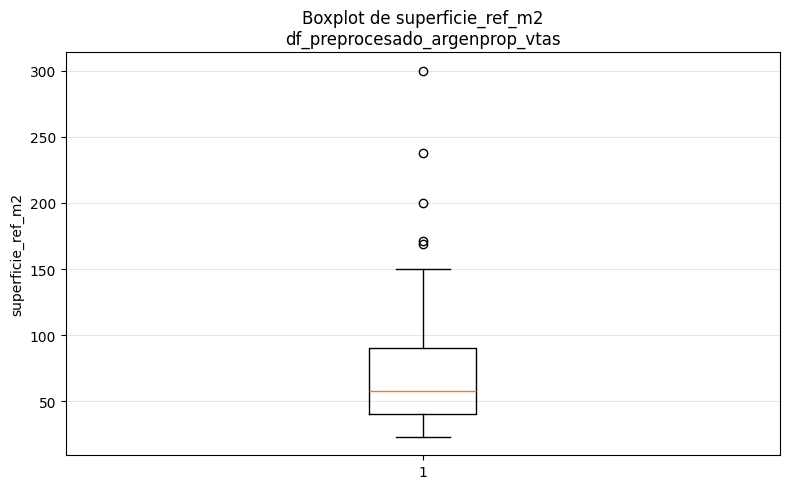

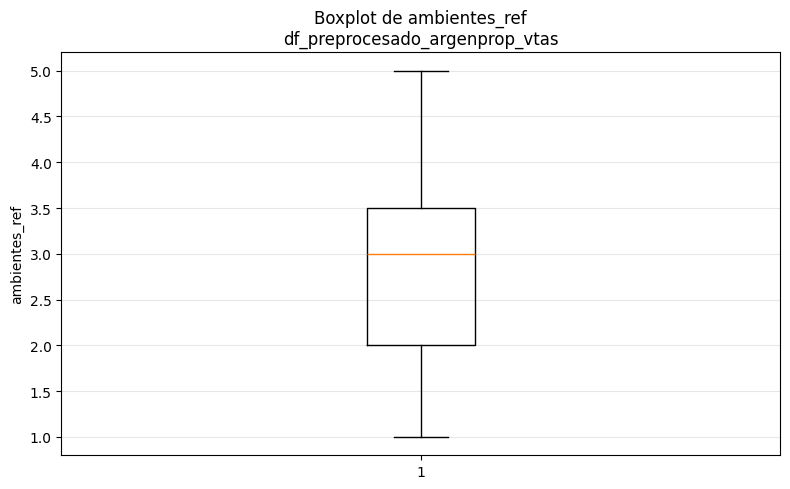

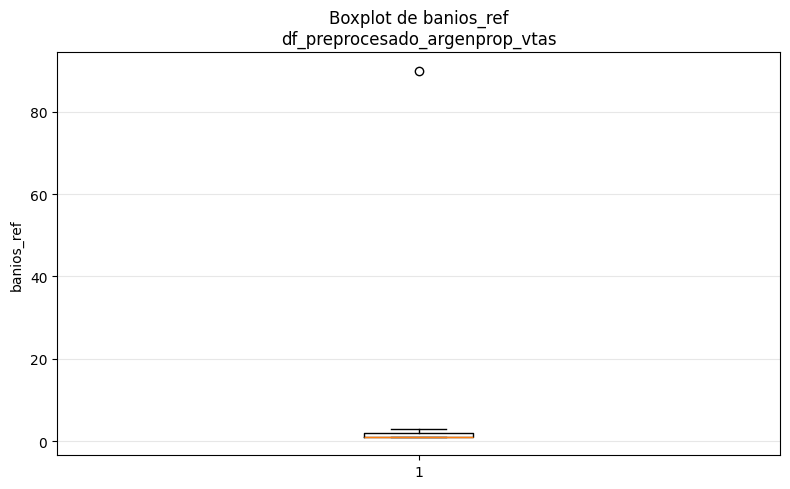

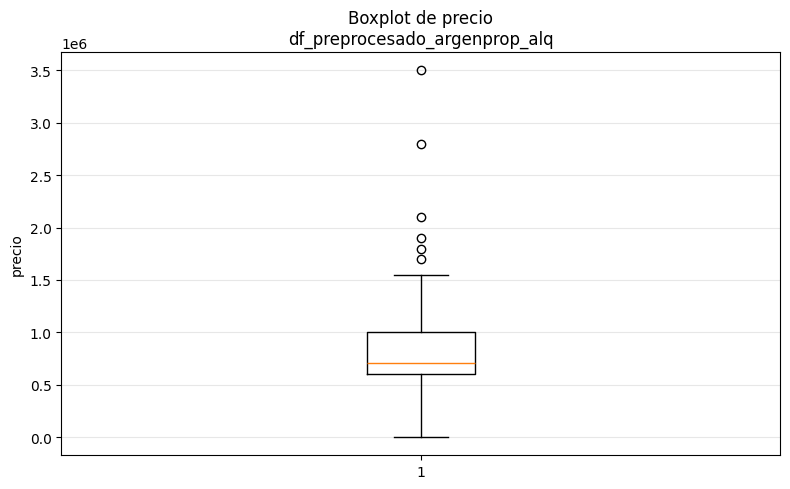

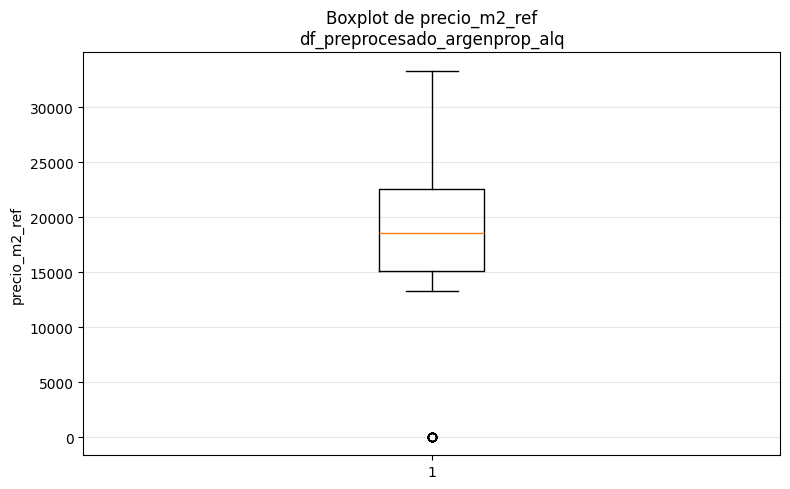

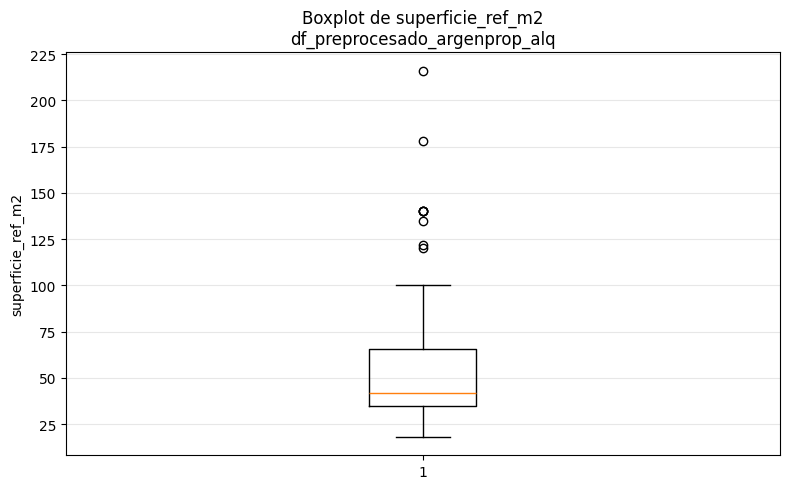

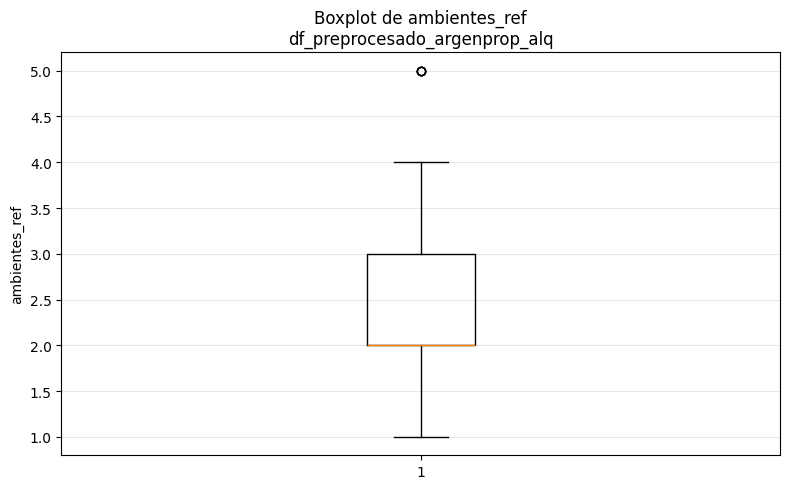

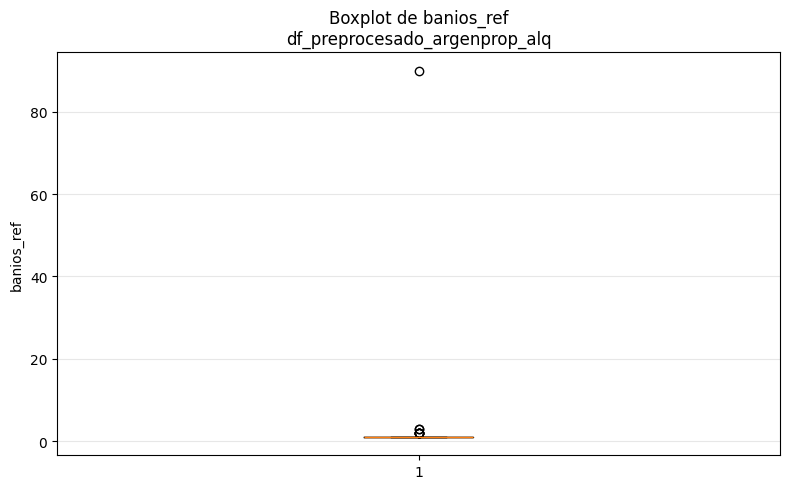

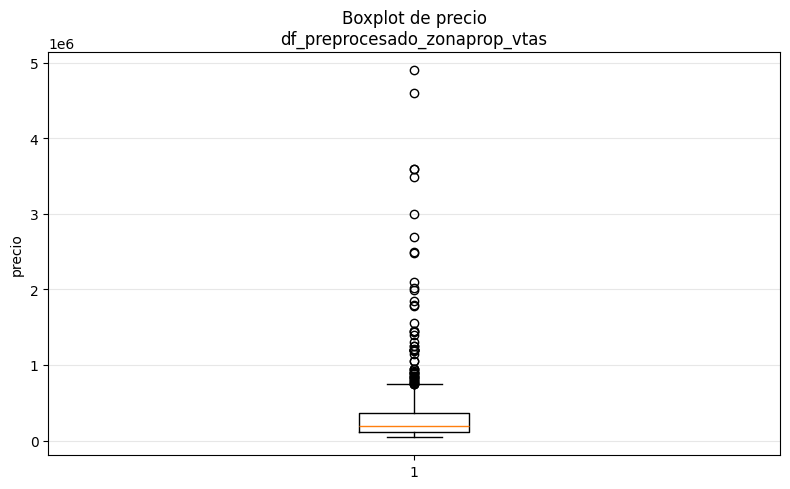

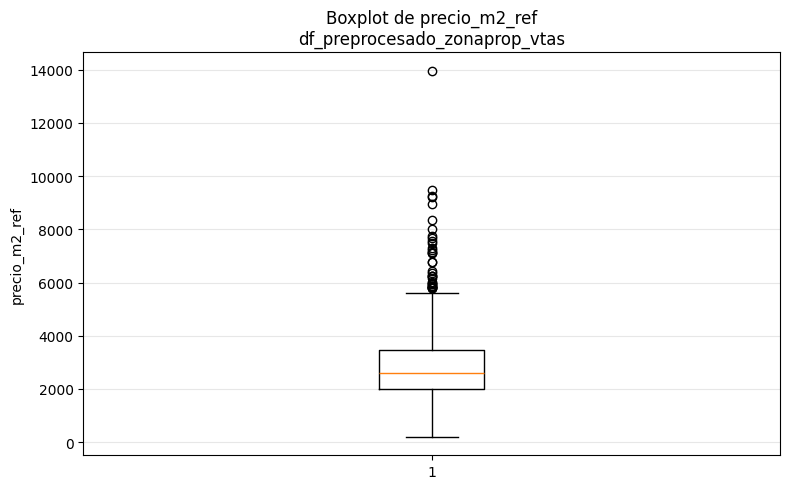

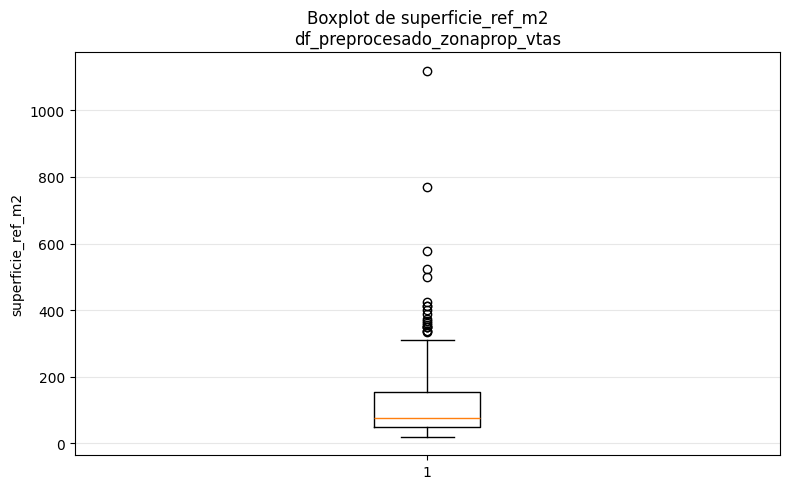

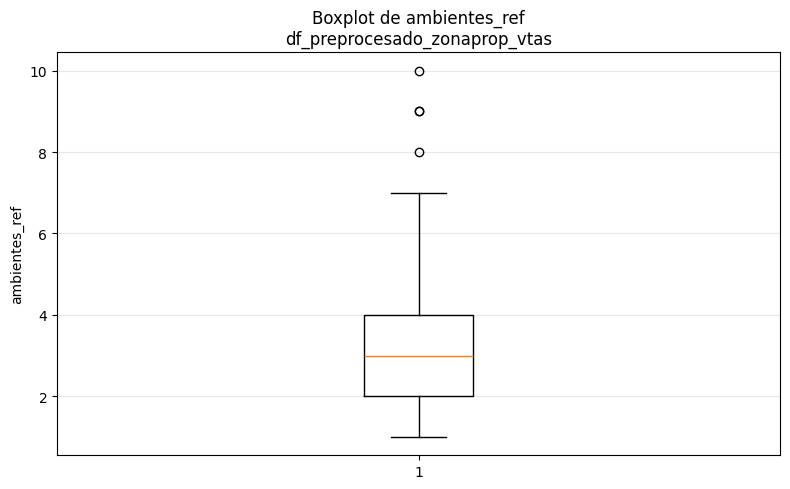

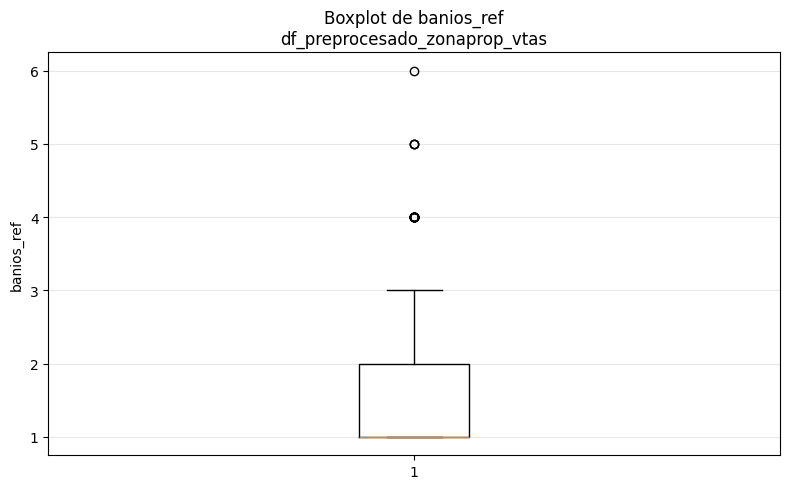

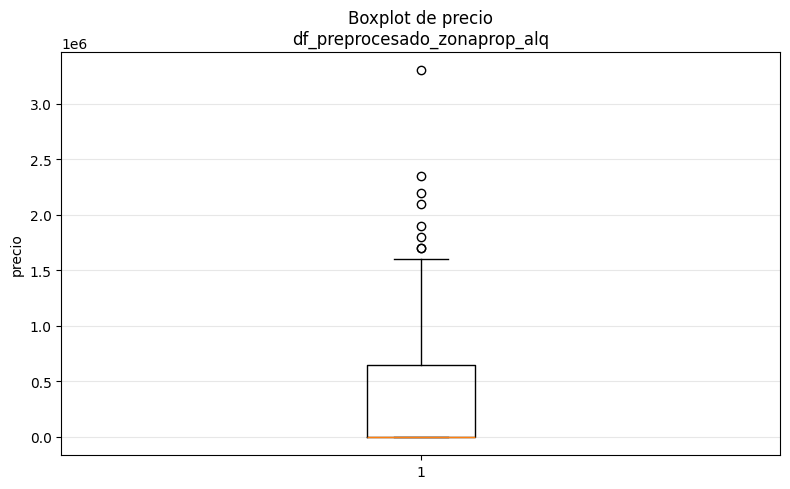

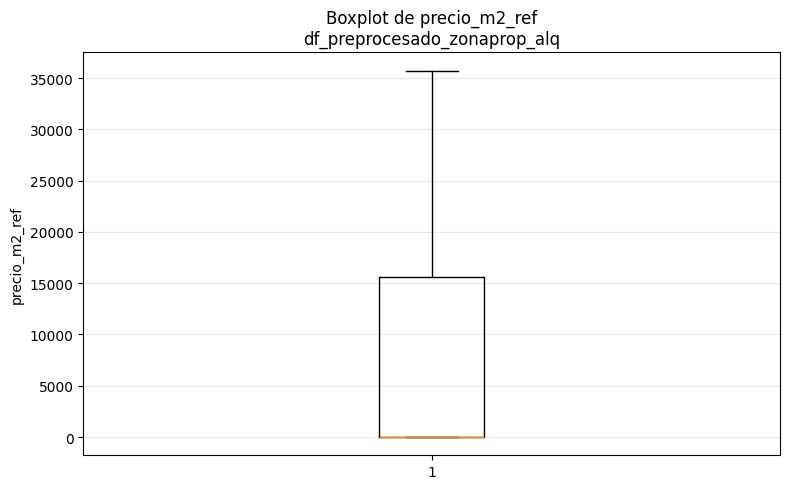

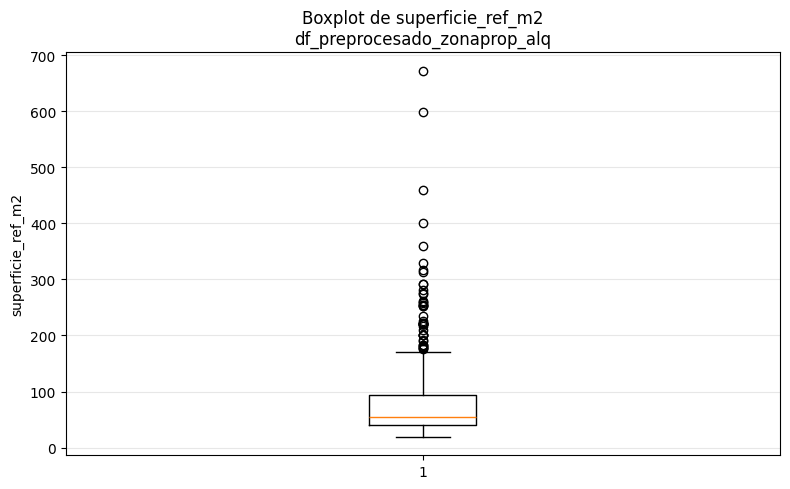

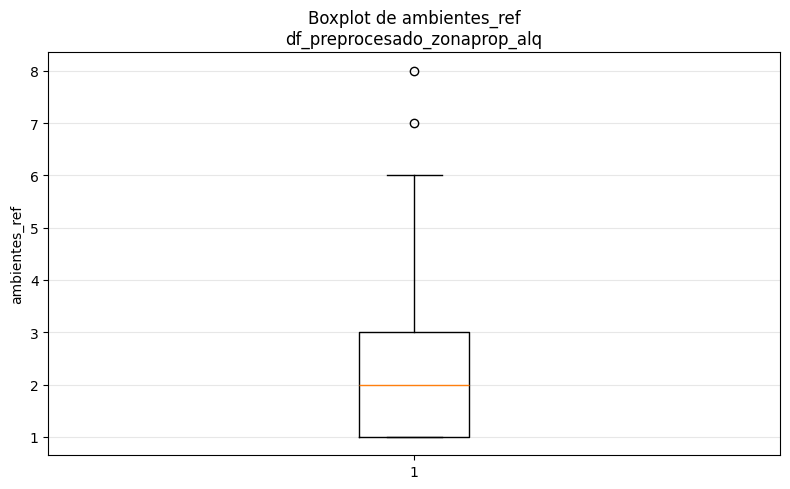

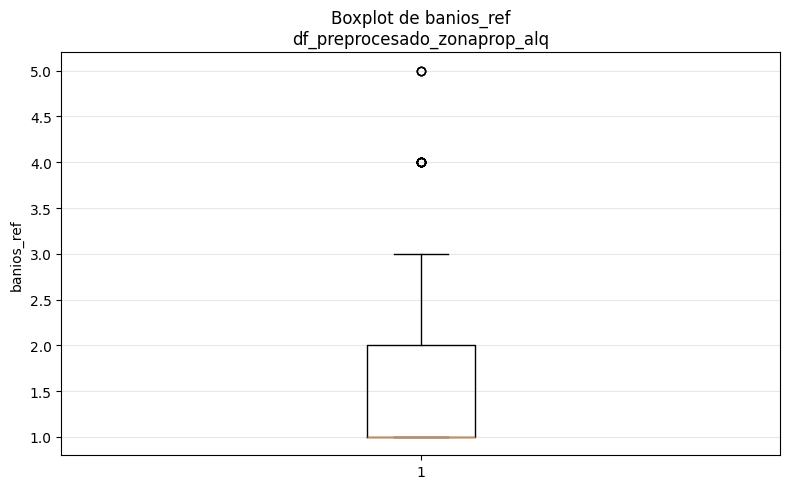

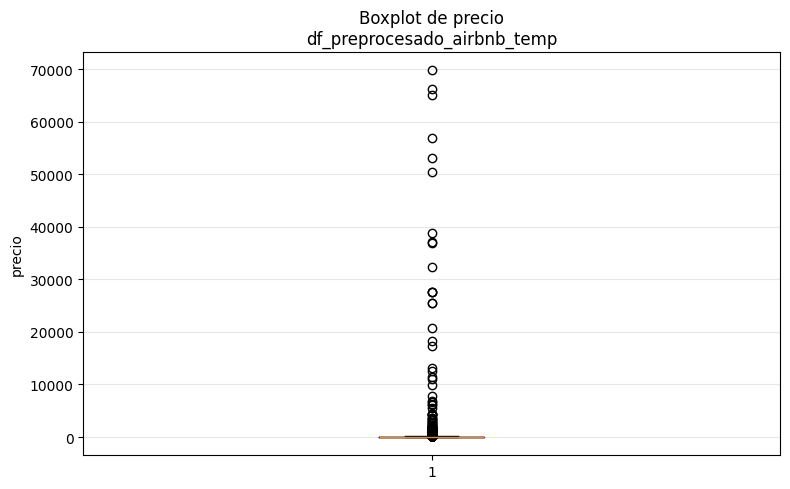

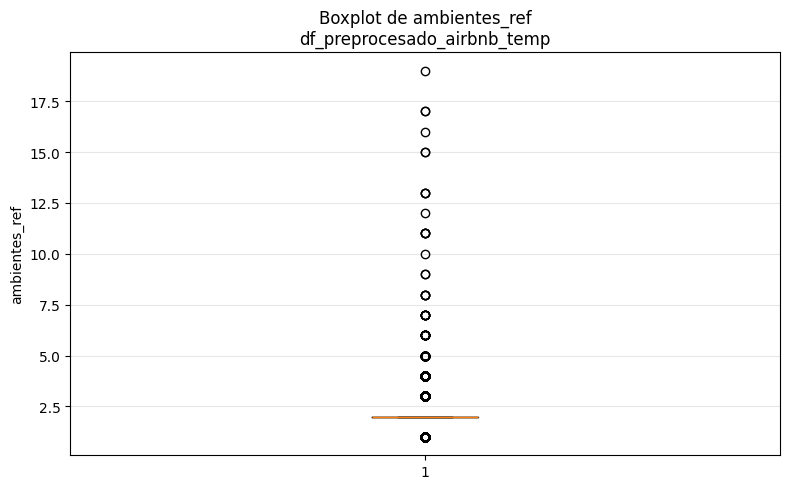

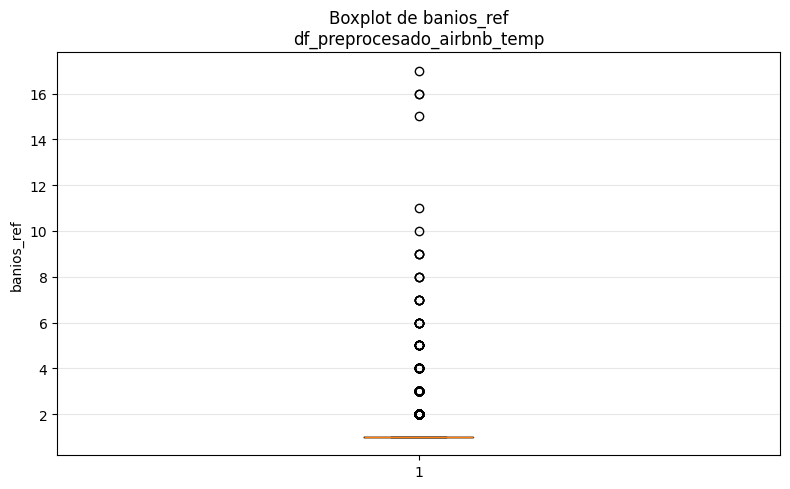

In [10]:
# ============================================================
# VISUALIZACIÓN DE OUTLIERS
# BOXPLOTS
# ============================================================

import matplotlib.pyplot as plt

VARIABLES_BOXPLOT = [
    'precio',
    'precio_m2_ref',
    'superficie_ref_m2',
    'ambientes_ref',
    'banios_ref'
]


for nombre, df in preprocesados_con_iqr.items():

    for variable in VARIABLES_BOXPLOT:

        if variable not in df.columns:
            continue

        valores = pd.to_numeric(
            df[variable],
            errors='coerce'
        )

        valores = valores[
            valores > 0
        ].dropna()

        if len(valores) < 5:
            continue

        plt.figure(figsize=(8, 5))

        plt.boxplot(
            valores,
            vert=True,
            showfliers=True
        )

        plt.title(
            f'Boxplot de {variable}\n{nombre}'
        )

        plt.ylabel(variable)

        plt.grid(
            axis='y',
            alpha=0.3
        )

        plt.tight_layout()
        plt.show()

## Boxplots en escala logarítmica

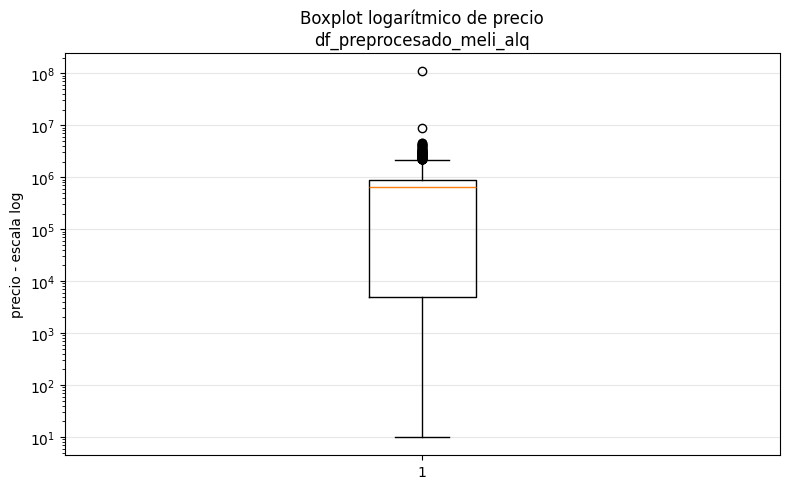

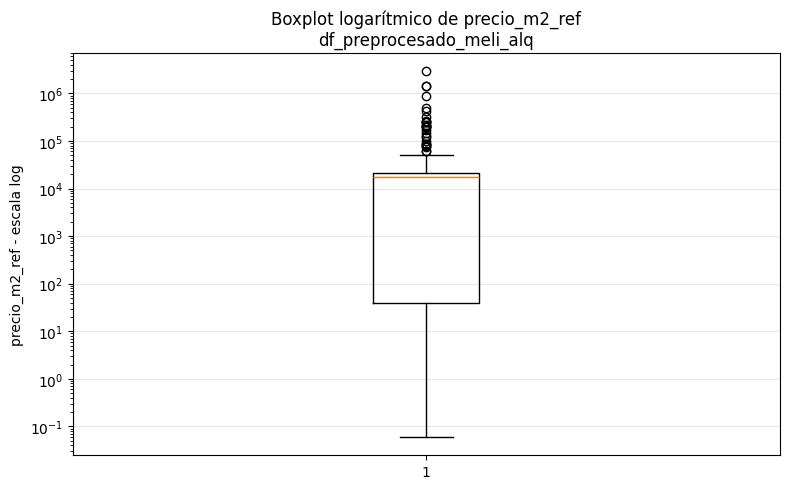

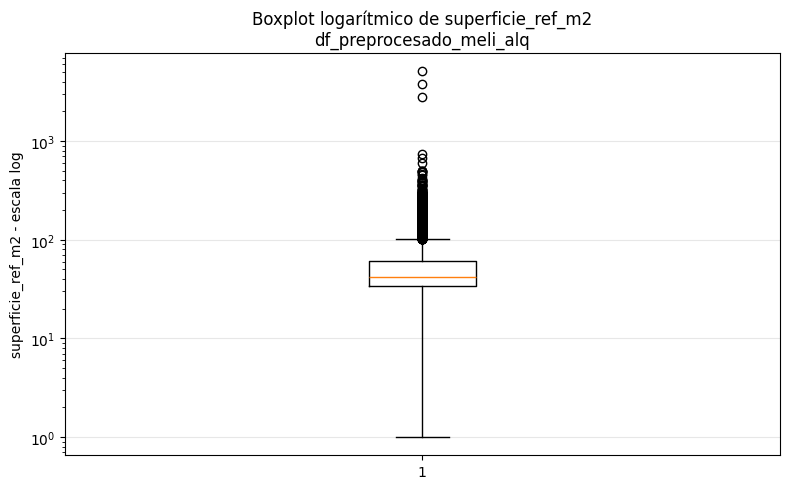

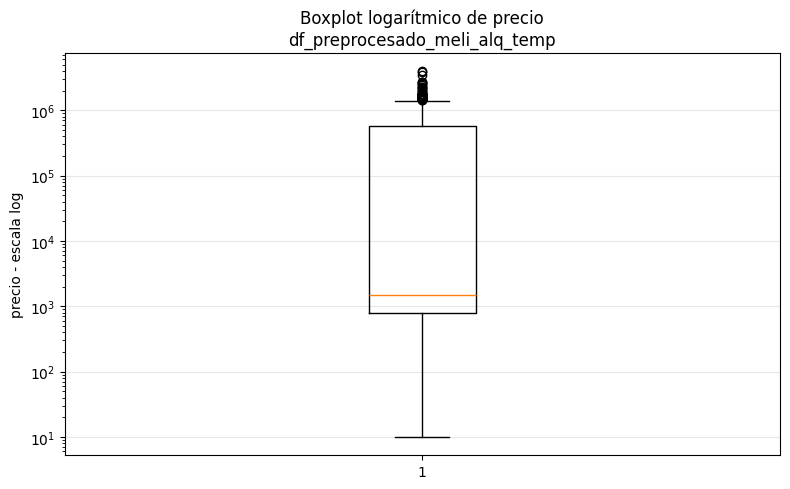

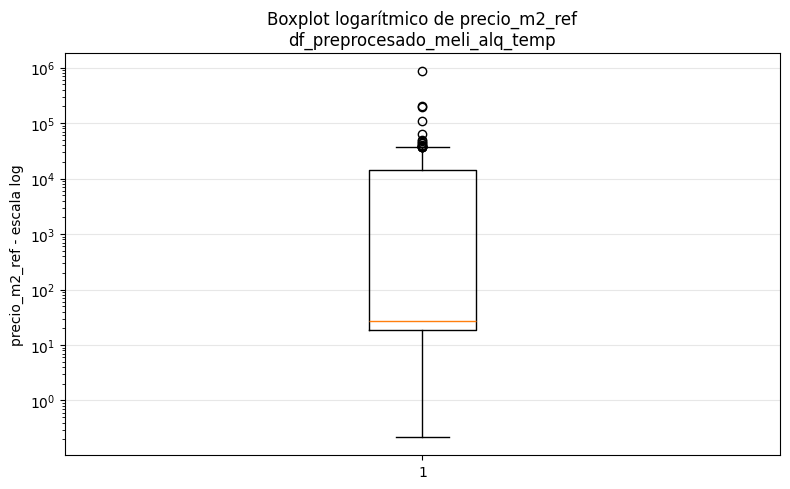

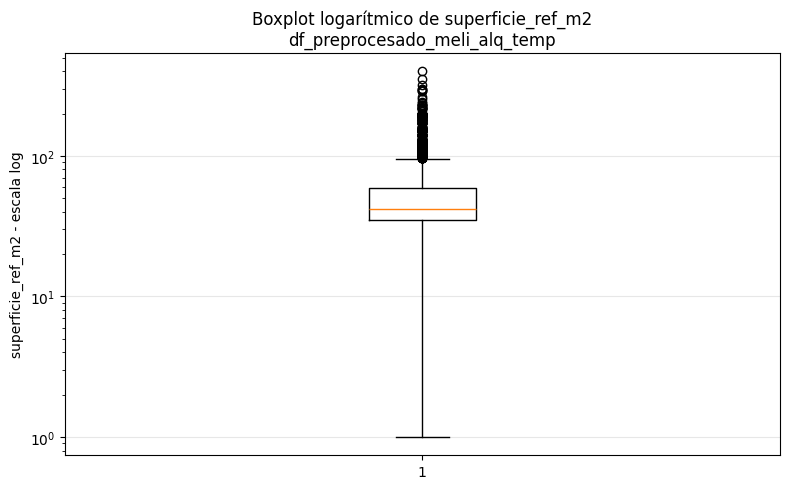

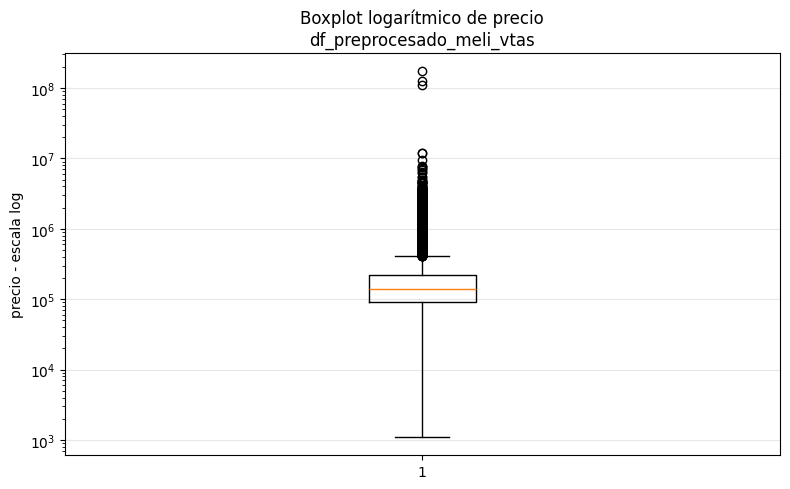

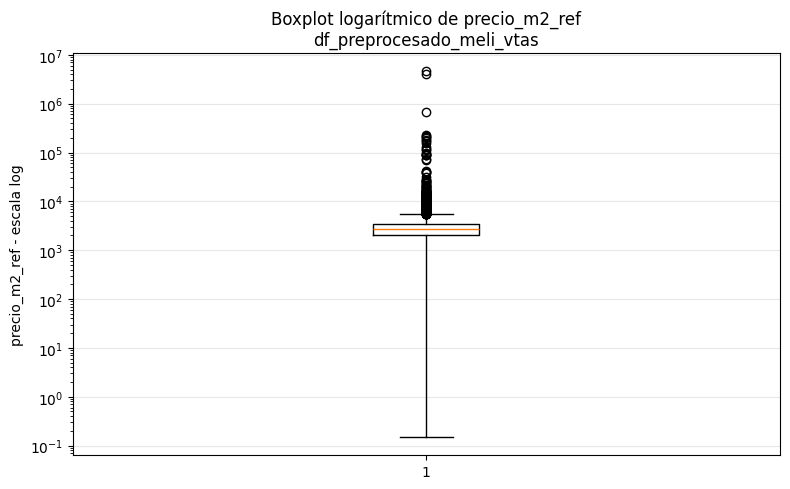

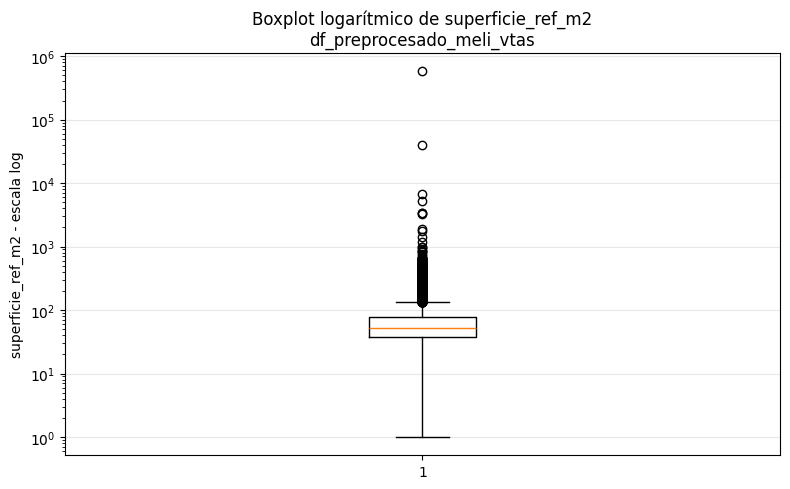

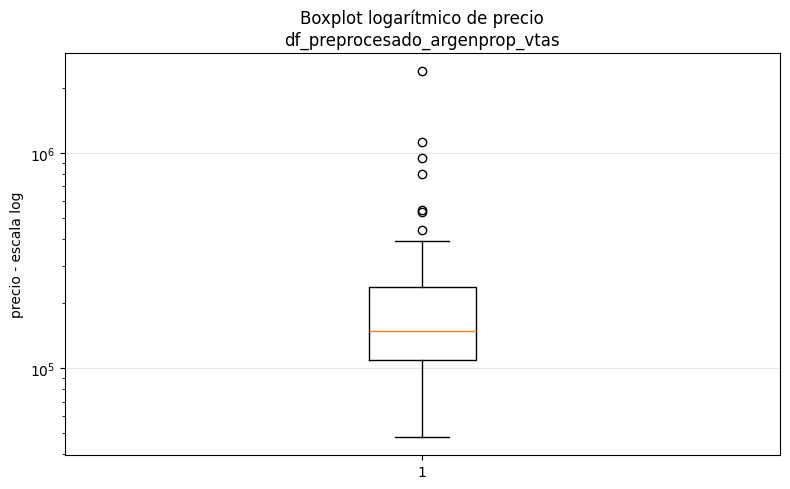

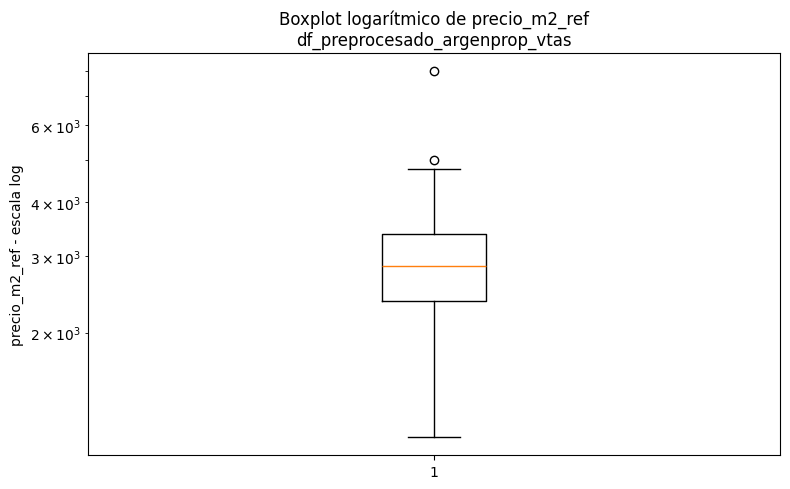

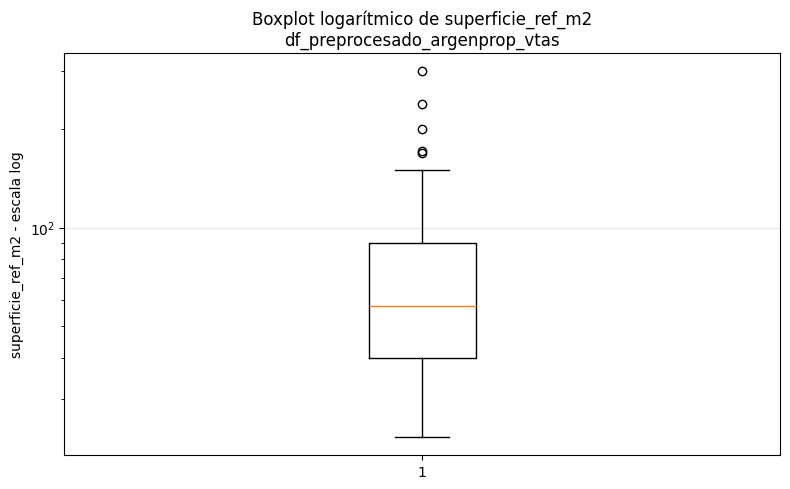

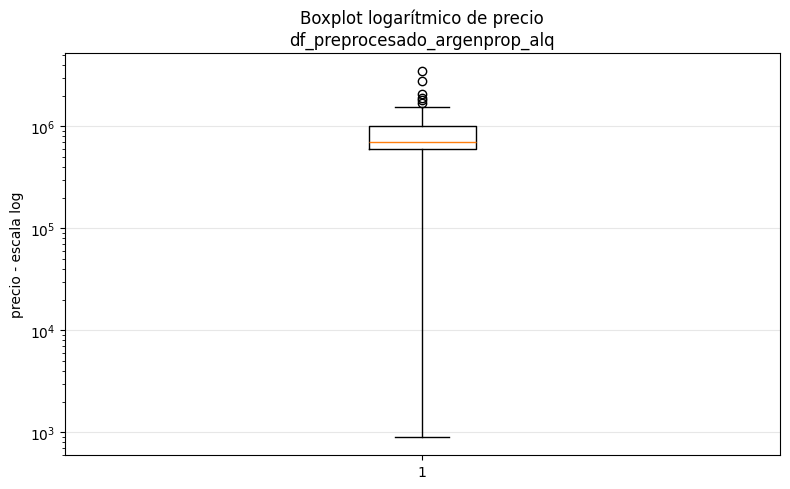

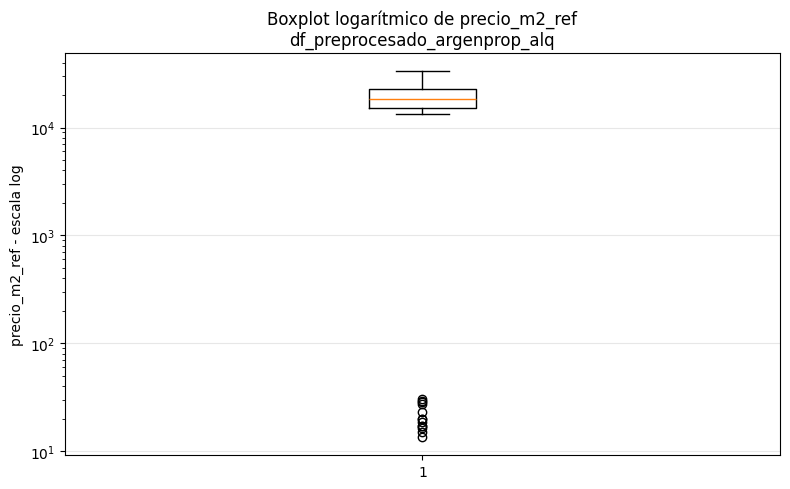

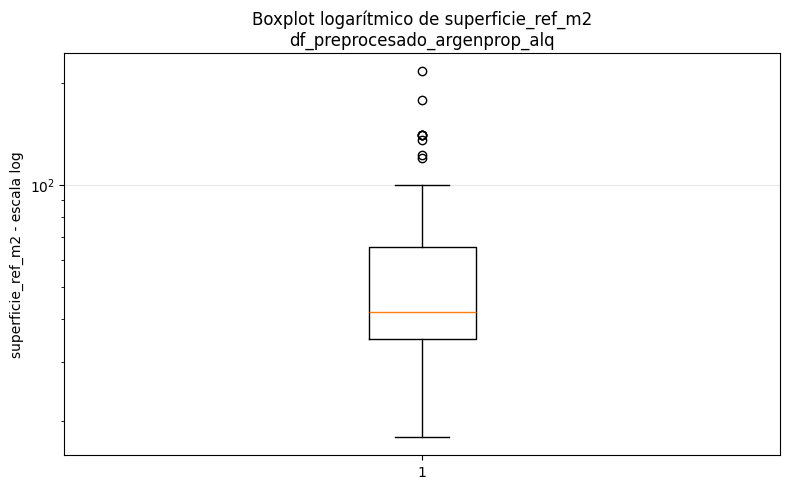

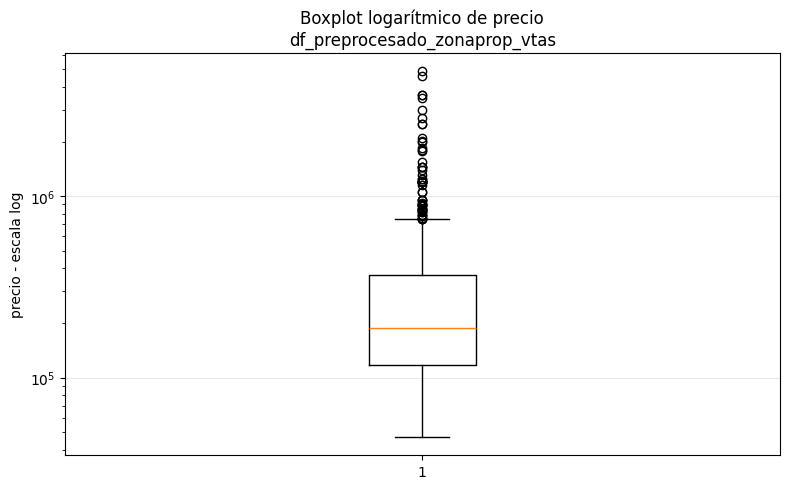

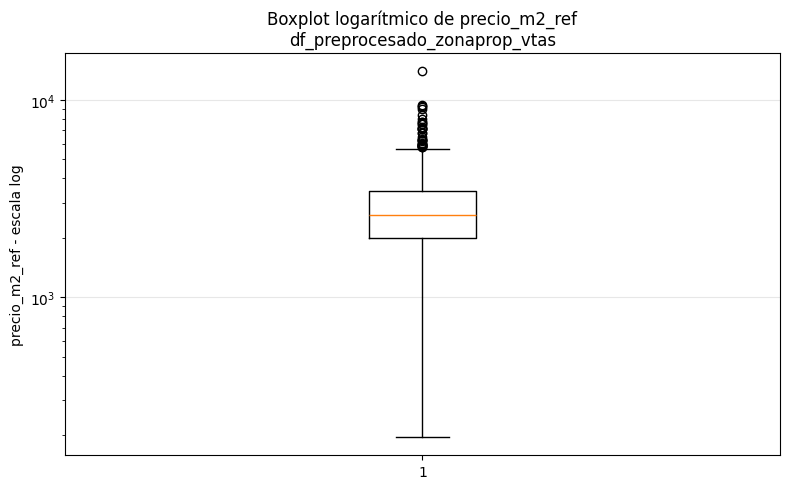

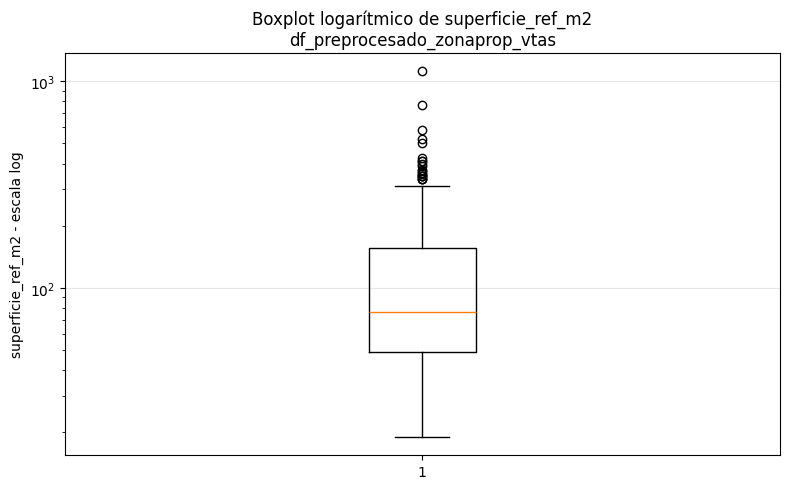

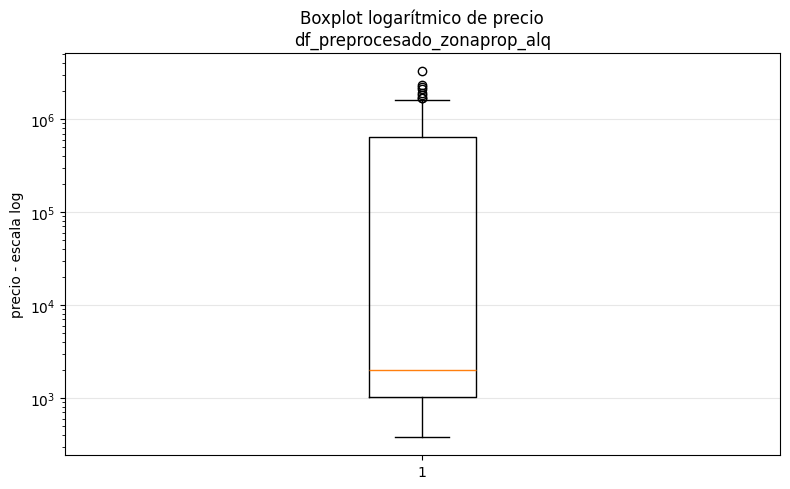

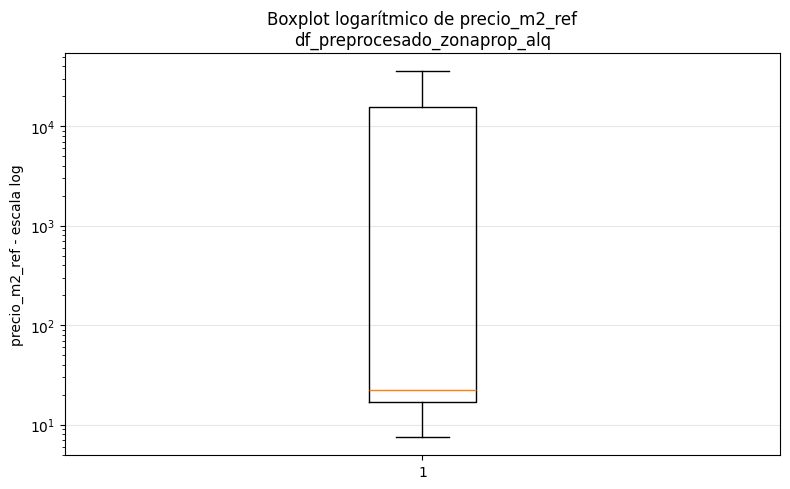

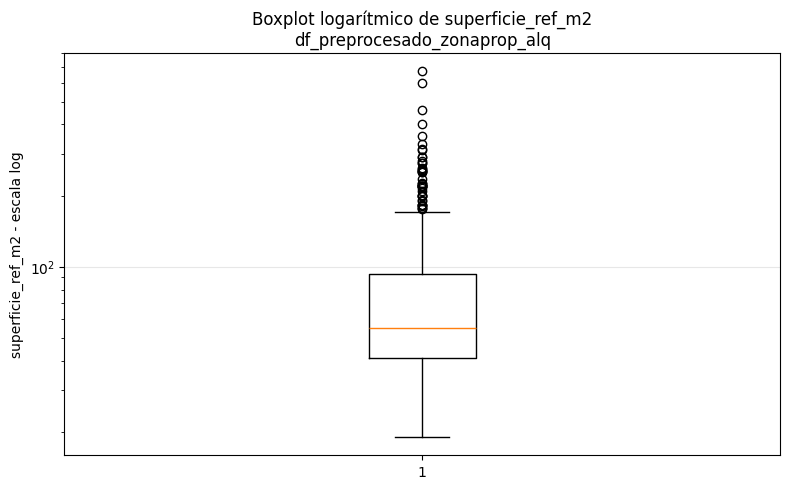

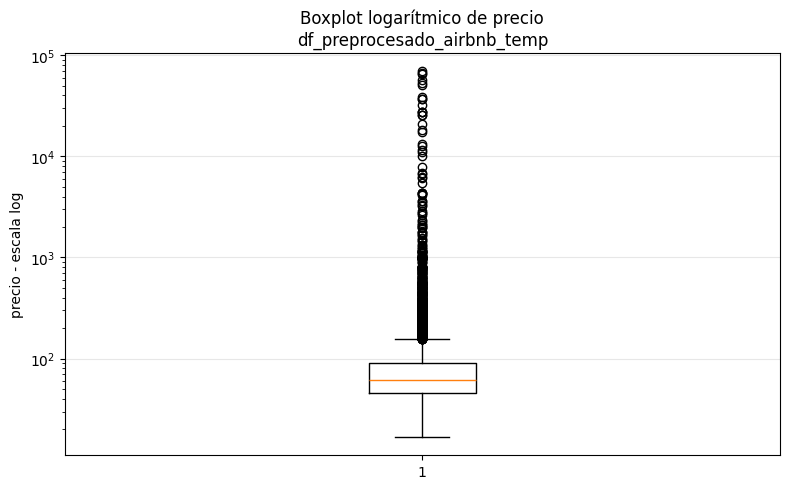

In [11]:
# ============================================================
# BOXPLOTS EN ESCALA LOGARÍTMICA
# ============================================================

VARIABLES_LOG = [
    'precio',
    'precio_m2_ref',
    'superficie_ref_m2'
]


for nombre, df in preprocesados_con_iqr.items():

    for variable in VARIABLES_LOG:

        if variable not in df.columns:
            continue

        valores = pd.to_numeric(
            df[variable],
            errors='coerce'
        )

        valores = valores[
            valores > 0
        ].dropna()

        if len(valores) < 5:
            continue

        plt.figure(figsize=(8, 5))

        plt.boxplot(
            valores,
            showfliers=True
        )

        plt.yscale('log')

        plt.title(
            f'Boxplot logarítmico de {variable}\n{nombre}'
        )

        plt.ylabel(
            f'{variable} - escala log'
        )

        plt.grid(
            axis='y',
            alpha=0.3
        )

        plt.tight_layout()
        plt.show()

## Scatterplot Precio vs Superficie

Para tratar de buscar outliers multivariados, se visualiza la relación entre precio y superficie en scatterplots en las distintas plataformas.

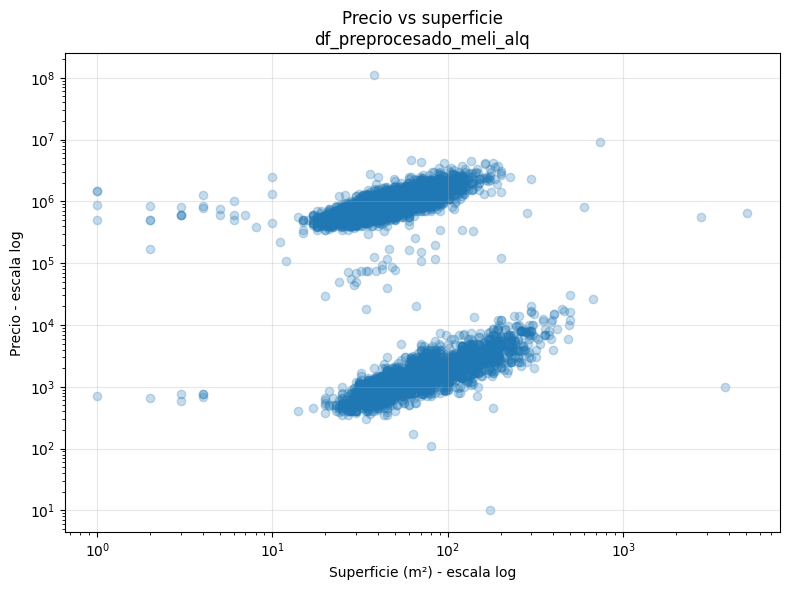

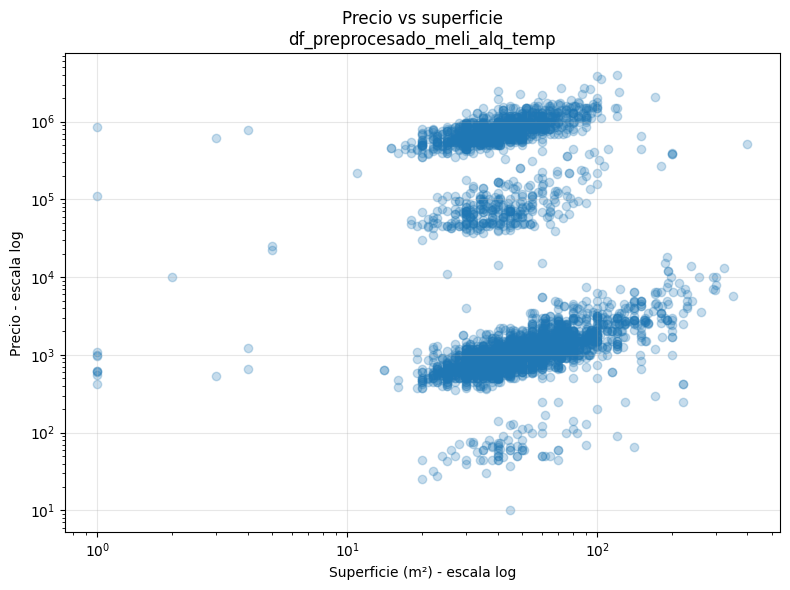

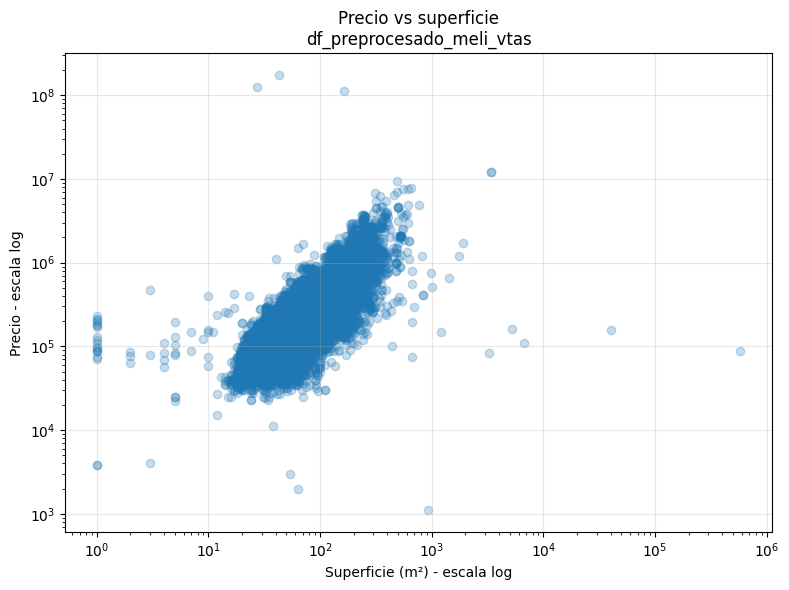

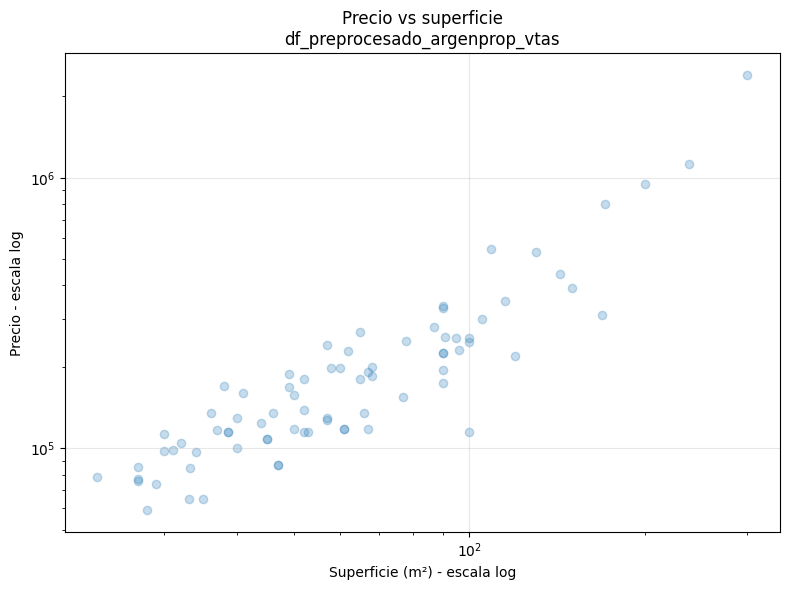

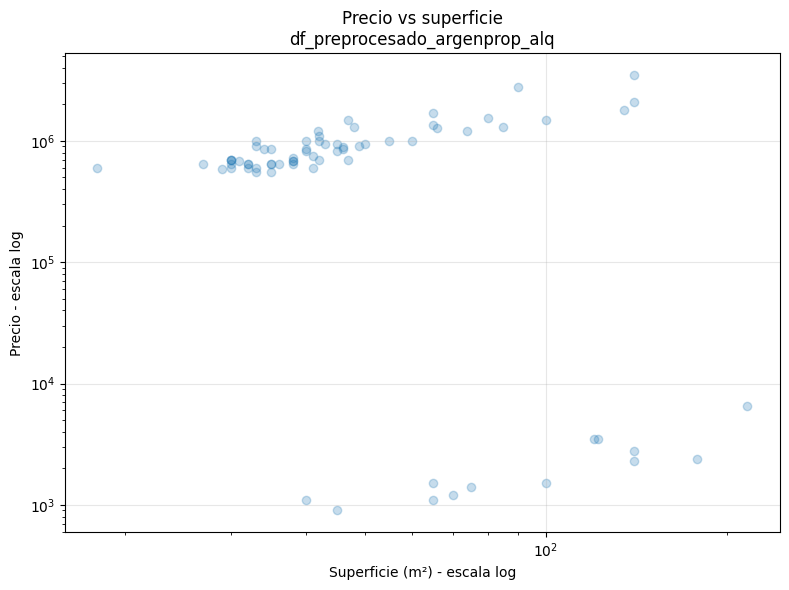

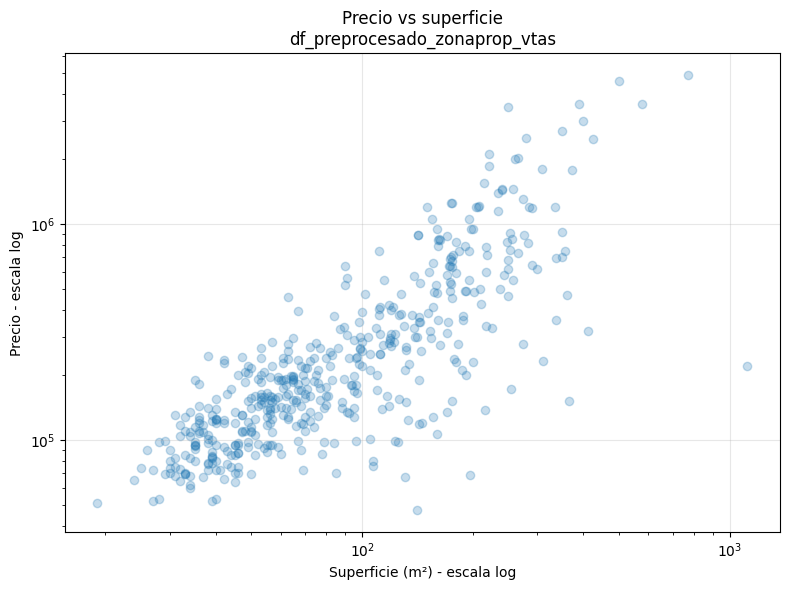

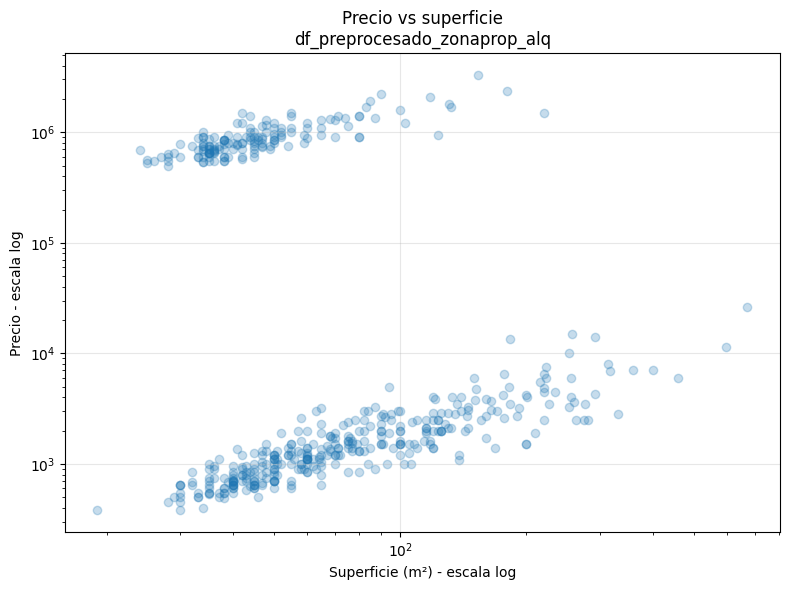

In [12]:
# ============================================================
# SCATTER: PRECIO VS SUPERFICIE
# ============================================================

for nombre, df in preprocesados_con_iqr.items():

    if (
        'precio' not in df.columns
        or
        'superficie_ref_m2' not in df.columns
    ):
        continue

    datos = df[
        [
            'precio',
            'superficie_ref_m2'
        ]
    ].copy()

    datos['precio'] = pd.to_numeric(
        datos['precio'],
        errors='coerce'
    )

    datos['superficie_ref_m2'] = pd.to_numeric(
        datos['superficie_ref_m2'],
        errors='coerce'
    )

    datos = datos[
        (datos['precio'] > 0) &
        (datos['superficie_ref_m2'] > 0)
    ].dropna()

    if len(datos) < 10:
        continue

    plt.figure(figsize=(8, 6))

    plt.scatter(
        datos['superficie_ref_m2'],
        datos['precio'],
        alpha=0.25
    )

    plt.xscale('log')
    plt.yscale('log')

    plt.title(
        f'Precio vs superficie\n{nombre}'
    )

    plt.xlabel(
        'Superficie (m²) - escala log'
    )

    plt.ylabel(
        'Precio - escala log'
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

## Análisis Multivariado

In [13]:
# ============================================================
# OUTLIERS MULTIVARIADOS
# MAHALANOBIS ROBUSTO
# ============================================================

from sklearn.covariance import MinCovDet
from scipy.stats import chi2


VARIABLES_MULTIVARIADAS = [
    'precio',
    'superficie_ref_m2',
    'ambientes_ref',
    'dormitorios_ref',
    'banios_ref'
]


preprocesados_multivariado = {}

reportes_multivariado = []


for nombre, df in preprocesados_con_iqr.items():

    df_mv = df.copy()

    df_mv['outlier_multivariado_flag'] = 0

    # ---------------------------------------------
    # Variables disponibles
    # ---------------------------------------------

    variables = [
        v
        for v in VARIABLES_MULTIVARIADAS
        if v in df_mv.columns
    ]

    # ---------------------------------------------
    # Variables con suficiente información
    # ---------------------------------------------

    variables = [
        v
        for v in variables
        if df_mv[v].notna().mean() >= 0.60
    ]

    # Si hay menos de 3 variables, no se analiza
    if len(variables) < 3:

        print(
            nombre,
            '→ no hay suficientes variables'
        )

        preprocesados_multivariado[nombre] = df_mv

        continue

    # ---------------------------------------------
    # Seleccionar filas completas
    # ---------------------------------------------

    X = df_mv[variables].copy()

    X = X.dropna()

    # Mínimo de observaciones
    if len(X) < 50:

        print(
            nombre,
            '→ insuficientes observaciones'
        )

        preprocesados_multivariado[nombre] = df_mv

        continue

    # ---------------------------------------------
    # Transformación log del precio
    # ---------------------------------------------

    if 'precio' in X.columns:

        X['precio'] = np.log1p(
            X['precio'].clip(lower=0)
        )

    # ---------------------------------------------
    # Modelo robusto
    # ---------------------------------------------

    try:

        modelo = MinCovDet(
            random_state=42
        )

        modelo.fit(X)

        distancias = modelo.mahalanobis(X)

        umbral = chi2.ppf(
            0.99,
            df=len(variables)
        )

        flags = distancias > umbral

        df_mv.loc[
            X.index,
            'outlier_multivariado_flag'
        ] = flags.astype(int)

        n_outliers = int(
            flags.sum()
        )

        pct_outliers = round(
            100 * n_outliers / len(X),
            2
        )

        reportes_multivariado.append({
            'dataset': nombre,
            'variables': ', '.join(variables),
            'n_evaluados': len(X),
            'n_outliers': n_outliers,
            'pct_outliers': pct_outliers
        })

        print(
            nombre,
            '→',
            n_outliers,
            'outliers multivariados',
            f'({pct_outliers}%)'
        )

    except Exception as e:

        print(
            nombre,
            '→ error:',
            e
        )

    preprocesados_multivariado[nombre] = df_mv


reporte_multivariado = pd.DataFrame(
    reportes_multivariado
)

display(
    reporte_multivariado
)

df_preprocesado_meli_alq → 3578 outliers multivariados (38.05%)
df_preprocesado_meli_alq_temp → 527 outliers multivariados (12.41%)
df_preprocesado_meli_vtas → 9420 outliers multivariados (22.74%)
df_preprocesado_argenprop_vtas → 12 outliers multivariados (18.18%)
df_preprocesado_argenprop_alq → 21 outliers multivariados (36.21%)
df_preprocesado_zonaprop_vtas → 93 outliers multivariados (25.2%)
df_preprocesado_zonaprop_alq → 137 outliers multivariados (35.86%)


c:\Users\arira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-2.706733794108497 > -34.636185779310907). You may want to try with a higher value of support_fraction (current value: 0.545).
  warnings.warn(
c:\Users\arira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-2.519638460477454 > -31.629623064194039). You may want to try with a higher value of support_fraction (current value: 0.545).
  warnings.warn(
c:\Users\arira\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\covariance\_robust_covariance.py:188: RuntimeWarning: Determinant has increased; this should not happen: log(det) > log(previous_det) (-2.666506239667382 > -34.833849614161281). You may want to try w

df_preprocesado_airbnb_temp → 1281 outliers multivariados (13.36%)


,dataset,variables,n_evaluados,n_outliers,pct_outliers
0,df_preprocesado_meli_alq,"precio, superficie_ref_m2, ambientes_ref, bani...",9403,3578,38.05
1,df_preprocesado_meli_alq_temp,"precio, superficie_ref_m2, ambientes_ref, bani...",4248,527,12.41
2,df_preprocesado_meli_vtas,"precio, superficie_ref_m2, ambientes_ref, bani...",41421,9420,22.74
3,df_preprocesado_argenprop_vtas,"precio, superficie_ref_m2, ambientes_ref, dorm...",66,12,18.18
4,df_preprocesado_argenprop_alq,"precio, superficie_ref_m2, ambientes_ref, dorm...",58,21,36.21
5,df_preprocesado_zonaprop_vtas,"precio, superficie_ref_m2, ambientes_ref, dorm...",369,93,25.20
6,df_preprocesado_zonaprop_alq,"precio, superficie_ref_m2, ambientes_ref, dorm...",382,137,35.86
7,df_preprocesado_airbnb_temp,"precio, ambientes_ref, dormitorios_ref, banios...",9588,1281,13.36


## Consenso entre métodos

Buscamos aquellos registros que se detectaron como outliers para los tres métodos: P01-P99, IQR y Mahalanobis.

In [14]:
# ============================================================
# CONSENSO DE MÉTODOS
# ============================================================

resultados_finales = {}

for nombre, df in preprocesados_multivariado.items():

    resultado = df.copy()

    # ---------------------------------------------
    # Flags P01-P99
    # ---------------------------------------------

    flags_p01 = [
        c for c in resultado.columns
        if c.endswith(
            '_outlier_p01_p99_flag'
        )
    ]

    if flags_p01:

        resultado['n_flags_p01_p99'] = (
            resultado[flags_p01]
            .fillna(0)
            .astype(int)
            .sum(axis=1)
        )

    else:

        resultado['n_flags_p01_p99'] = 0

    # ---------------------------------------------
    # Flags IQR
    # ---------------------------------------------

    flags_iqr = [
        c for c in resultado.columns
        if c.endswith(
            '_outlier_iqr_flag'
        )
    ]

    if flags_iqr:

        resultado['n_flags_iqr'] = (
            resultado[flags_iqr]
            .fillna(0)
            .astype(int)
            .sum(axis=1)
        )

    else:

        resultado['n_flags_iqr'] = 0

    # ---------------------------------------------
    # Cantidad de métodos
    # ---------------------------------------------

    resultado[
        'cantidad_metodos_outlier'
    ] = (
        (resultado['n_flags_p01_p99'] > 0)
        .astype(int)
        +
        (resultado['n_flags_iqr'] > 0)
        .astype(int)
        +
        resultado[
            'outlier_multivariado_flag'
        ].astype(int)
    )

    # ---------------------------------------------
    # Clasificación
    # ---------------------------------------------

    resultado[
        'nivel_revision_outlier'
    ] = 'sin_alerta'

    resultado.loc[
        resultado['cantidad_metodos_outlier'] >= 1,
        'nivel_revision_outlier'
    ] = 'revisar'

    resultado.loc[
        resultado['cantidad_metodos_outlier'] >= 2,
        'nivel_revision_outlier'
    ] = 'prioridad_alta'

    resultado.loc[
        resultado['cantidad_metodos_outlier'] == 3,
        'nivel_revision_outlier'
    ] = 'prioridad_maxima'

    resultados_finales[nombre] = resultado

## Resumen Final

In [15]:
# ============================================================
# RESUMEN FINAL DE OUTLIERS
# ============================================================

resumen_final = []

for nombre, df in resultados_finales.items():

    total = len(df)

    conteo = (
        df['nivel_revision_outlier']
        .value_counts()
    )

    for nivel, cantidad in conteo.items():

        resumen_final.append({
            'dataset': nombre,
            'nivel_revision_outlier': nivel,
            'cantidad': int(cantidad),
            'porcentaje': round(
                100 * cantidad / total,
                2
            )
        })


resumen_final = pd.DataFrame(
    resumen_final
)

display(
    resumen_final
)

,dataset,nivel_revision_outlier,cantidad,porcentaje
0,df_preprocesado_meli_alq,sin_alerta,5867,59.40
1,df_preprocesado_meli_alq,revisar,2383,24.13
2,df_preprocesado_meli_alq,prioridad_alta,1299,13.15
3,df_preprocesado_meli_alq,prioridad_maxima,328,3.32
4,df_preprocesado_meli_alq_temp,sin_alerta,3195,71.09
5,df_preprocesado_meli_alq_temp,revisar,744,16.56
6,df_preprocesado_meli_alq_temp,prioridad_alta,458,10.19
7,df_preprocesado_meli_alq_temp,prioridad_maxima,97,2.16
8,df_preprocesado_meli_vtas,sin_alerta,31165,72.85
9,df_preprocesado_meli_vtas,revisar,5944,13.89


## Resumen Gráfico

Aviso: niveles no contemplados en colores/orden predefinidos: ['prioridad_maxima']


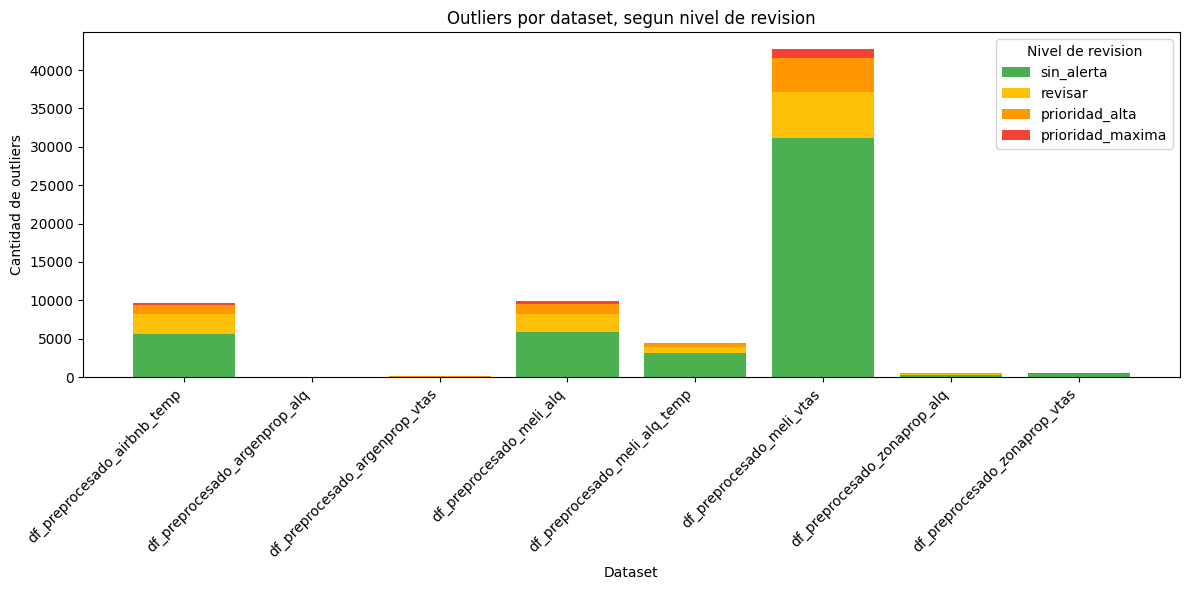

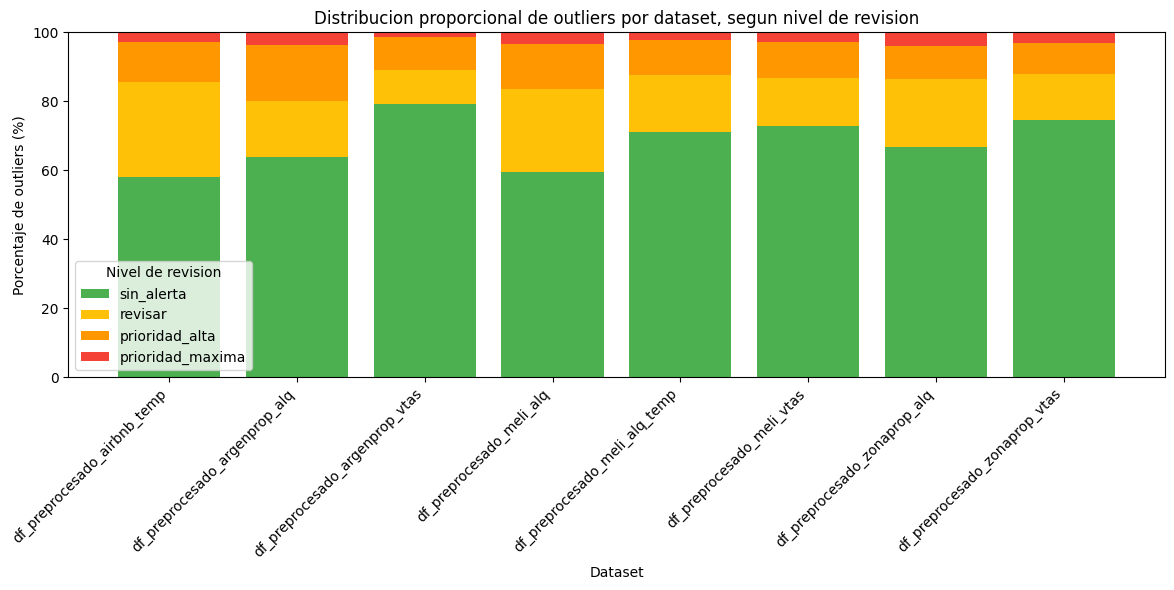

In [16]:
# --- Grafico: cantidad de outliers por dataset, segun nivel de revision ---

orden_niveles = ['sin_alerta', 'revisar', 'prioridad_baja', 'prioridad_alta']
colores_niveles = {
    'sin_alerta': '#4CAF50',      # verde
    'revisar': '#FFC107',         # amarillo
    'prioridad_alta': '#FF9800',  # naranja
    'prioridad_maxima': '#F44336',  # rojo
}

niveles_presentes = [n for n in orden_niveles if n in resumen_final['nivel_revision_outlier'].unique()]
niveles_extra = [n for n in resumen_final['nivel_revision_outlier'].unique() if n not in orden_niveles]
if niveles_extra:
    print(f'Aviso: niveles no contemplados en colores/orden predefinidos: {niveles_extra}')
orden_final = niveles_presentes + niveles_extra

pivot_resumen = resumen_final.pivot_table(
    index='dataset', columns='nivel_revision_outlier', values='cantidad',
    aggfunc='sum', fill_value=0,
)[orden_final]

plt.figure(figsize=(12, 6))
bottom = np.zeros(len(pivot_resumen))
for nivel in orden_final:
    plt.bar(
        pivot_resumen.index, pivot_resumen[nivel], bottom=bottom,
        label=nivel, color=colores_niveles.get(nivel),
    )
    bottom += pivot_resumen[nivel].values

plt.xlabel('Dataset')
plt.ylabel('Cantidad de outliers')
plt.title('Outliers por dataset, segun nivel de revision')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nivel de revision')
plt.tight_layout()
plt.show()

# --- Grafico: proporcion de outliers por dataset, segun nivel de revision (barras apiladas al 100%) ---

pivot_resumen_pct = pivot_resumen.div(pivot_resumen.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
bottom = np.zeros(len(pivot_resumen_pct))
for nivel in orden_final:
    plt.bar(
        pivot_resumen_pct.index, pivot_resumen_pct[nivel], bottom=bottom,
        label=nivel, color=colores_niveles.get(nivel),
    )
    bottom += pivot_resumen_pct[nivel].values

plt.xlabel('Dataset')
plt.ylabel('Porcentaje de outliers (%)')
plt.title('Distribucion proporcional de outliers por dataset, segun nivel de revision')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nivel de revision')
plt.tight_layout()
plt.show()

## Celdas de decisión: tratamiento de valores inválidos y outliers

La estrategia por defecto es **marcar** valores inválidos y extremos. No se eliminan outliers plausibles porque en el mercado inmobiliario pueden representar propiedades reales. Si se decide limpiar de forma activa, se recomienda transformar a nulo solo valores imposibles y documentar el impacto.

In [17]:
# Parametros conservadores.
NULIFICAR_VALORES_INVALIDOS = False
ELIMINAR_OUTLIERS_P01_P99 = False

resumen_decisiones_outliers = []
for name, df in preprocesados_con_outliers.items():
    filas_antes = len(df)
    invalid_flags = [c for c in df.columns if c.endswith('_valor_invalido_flag')]
    outlier_flags = [c for c in df.columns if c.endswith('_outlier_p01_p99_flag')]

    filas_con_invalido = int(df[invalid_flags].any(axis=1).sum()) if invalid_flags else 0
    filas_con_outlier = int(df[outlier_flags].any(axis=1).sum()) if outlier_flags else 0

    if NULIFICAR_VALORES_INVALIDOS:
        for flag_col in invalid_flags:
            base_col = flag_col.replace('_valor_invalido_flag', '')
            if base_col in df.columns:
                df.loc[df[flag_col].eq(1), base_col] = np.nan

    if ELIMINAR_OUTLIERS_P01_P99 and outlier_flags:
        df = df.loc[~df[outlier_flags].any(axis=1)].copy()

    preprocesados_con_outliers[name] = df
    resumen_decisiones_outliers.append({
        'dataset': name,
        'filas_antes': filas_antes,
        'filas_con_valor_invalido': filas_con_invalido,
        'filas_con_outlier_p01_p99': filas_con_outlier,
        'nulificar_valores_invalidos': NULIFICAR_VALORES_INVALIDOS,
        'eliminar_outliers_p01_p99': ELIMINAR_OUTLIERS_P01_P99,
        'filas_despues': len(df),
    })

resumen_decisiones_outliers = pd.DataFrame(resumen_decisiones_outliers)
display(resumen_decisiones_outliers)
resumen_decisiones_outliers.to_csv(REPORTS_DIR / 'decisiones_tratamiento_outliers_v1.csv', index=False)

,dataset,filas_antes,filas_con_valor_invalido,filas_con_outlier_p01_p99,nulificar_valores_invalidos,eliminar_outliers_p01_p99,filas_despues
0,df_preprocesado_meli_alq,9877,0,617,False,False,9877
1,df_preprocesado_meli_alq_temp,4494,0,268,False,False,4494
2,df_preprocesado_meli_vtas,42778,0,2635,False,False,42778
3,df_preprocesado_argenprop_vtas,82,0,6,False,False,82
4,df_preprocesado_argenprop_alq,80,0,14,False,False,80
5,df_preprocesado_zonaprop_vtas,485,0,27,False,False,485
6,df_preprocesado_zonaprop_alq,495,0,33,False,False,495
7,df_preprocesado_airbnb_temp,9596,1650,767,False,False,9596


## Visualización resumida de outliers

pct_outliers_p01_p99
dataset                        variable                                     
df_preprocesado_argenprop_alq  altura                                   5.00
                               precio                                   5.00
                               precio_m2_ref                            5.00
                               superficie_ref_m2                        3.75
                               ambientes_ref                            2.50
df_preprocesado_argenprop_vtas precio_m2_ref                            2.44
                               superficie_ref_m2                        2.44
                               precio                                   2.44
df_preprocesado_zonaprop_alq   precio_m2_ref                            2.42
                               precio                                   2.22
df_preprocesado_zonaprop_vtas  precio_m2_ref                            2.06
df_preprocesado_zonaprop_alq   superficie_ref_m2                        2.02
df_preprocesado_meli_vtas      precio_m2_ref                            2.01
df_preprocesado_meli_alq       precio_m2_ref                            2.00
df_preprocesado_meli_alq_temp  precio_m2_ref                            2.00
df_preprocesado_airbnb_temp    latitud                                  1.99
                               precio                                   1.98
df_preprocesado_meli_alq_temp  precio                                   1.98
df_preprocesado_airbnb_temp    precio_mensual_estimado                  1.98
                               longitud                                 1.98
                               precio_noche_estimado                    1.98
df_preprocesado_meli_vtas      precio                                   1.97
df_preprocesado_zonaprop_vtas  precio                                   1.86
                               superficie_ref_m2                        1.86
df_preprocesado_meli_alq       superficie_ref_m2                        1.82
                               precio                                   1.75
df_preprocesado_meli_alq_temp  superficie_ref_m2                        1.69
df_preprocesado_meli_vtas      superficie_ref_m2                        1.69
df_preprocesado_meli_alq       altura                                   1.63
df_preprocesado_meli_vtas      altura                                   1.60
df_preprocesado_meli_alq_temp  altura                                   1.45
df_preprocesado_argenprop_alq  banios_ref                               1.25
                               dormitorios_ref                          1.25
df_preprocesado_argenprop_vtas banios_ref                               1.22
                               altura                                   1.22
df_preprocesado_airbnb_temp    ambientes_ref                            0.99
                               reviews                                  0.83
df_preprocesado_zonaprop_vtas  banios_ref                               0.82
                               ambientes_ref                            0.82
df_preprocesado_zonaprop_alq   ambientes_ref                            0.81

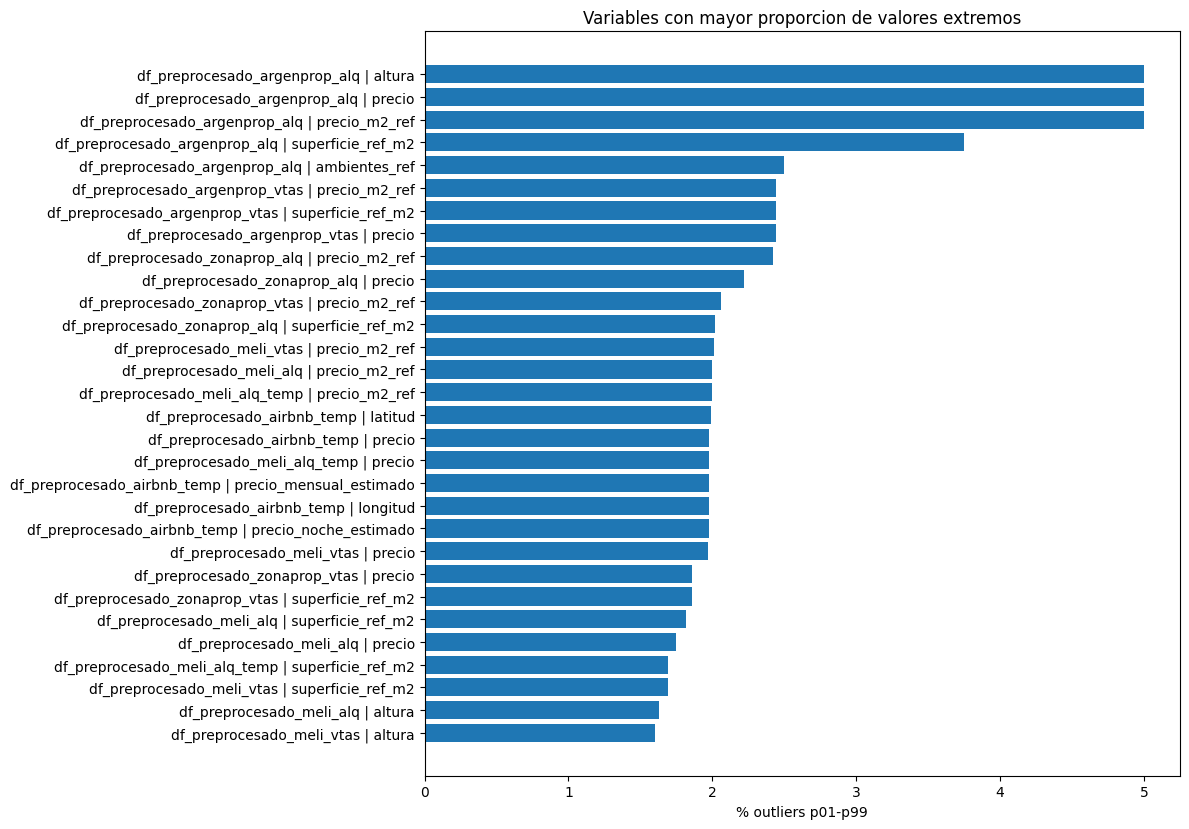

In [18]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    import matplotlib.pyplot as plt
    HAS_SEABORN = False

if not reporte_outliers.empty:
    pivot_outliers = reporte_outliers.pivot_table(index=['dataset', 'variable'], values='pct_outliers_p01_p99', aggfunc='mean').sort_values('pct_outliers_p01_p99', ascending=False)
    display(pivot_outliers.head(40))

    top_plot = pivot_outliers.head(30).reset_index()
    plt.figure(figsize=(12, max(5, len(top_plot) * 0.28)))
    labels = top_plot['dataset'] + ' | ' + top_plot['variable']
    plt.barh(labels, top_plot['pct_outliers_p01_p99'])
    plt.xlabel('% outliers p01-p99')
    plt.title('Variables con mayor proporcion de valores extremos')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Guardado de versiones con flags de outliers

In [19]:
# Se guardan las bases finales con los flags de outliers disponibles.
# Si se ejecutó el bloque IQR, se prioriza esa versión porque conserva tanto los flags p01-p99
# como los flags IQR. Si no, se guarda la versión p01-p99.
preprocesados_final_outliers = (
    preprocesados_con_iqr
    if 'preprocesados_con_iqr' in globals() and preprocesados_con_iqr
    else preprocesados_con_outliers
)

for name, df in preprocesados_final_outliers.items():
    path = PROCESSED_DIR / f'{name}_con_outliers_v1.csv'
    df.to_csv(path, index=False)
    print('Guardado:', path.relative_to(REPO_ROOT), df.shape)

canonical_cols = [
    'id_publicacion', 'fuente_norm', 'fuente', 'tipo_operacion_norm', 'tipo_operacion', 'url', 'fecha_extraccion',
    'scraped_at_utc', '_archivo_origen', 'titulo', 'descripcion', 'tipo_propiedad', 'moneda_norm', 'moneda',
    'precio', 'precio_texto', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'barrio',
    'barrio_norm', 'comuna', 'localidad', 'provincia', 'pais', 'direccion', 'direccion_completa', 'calle',
    'altura', 'latitud', 'longitud', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref'
]
frames = []
for name, df in preprocesados_final_outliers.items():
    cols = [c for c in df.columns if c in canonical_cols or c.endswith('_is_null') or c.endswith('_flag')]
    tmp = df[cols].copy()
    tmp['dataset_preprocesado'] = name
    frames.append(tmp)

df_publicaciones_consolidadas_outliers = pd.concat(frames, ignore_index=True, sort=False)
df_publicaciones_consolidadas_outliers.to_csv(PROCESSED_DIR / 'df_publicaciones_consolidadas_con_outliers_v1.csv', index=False)
print(df_publicaciones_consolidadas_outliers.shape)


Guardado: data\processed\df_preprocesado_meli_alq_con_outliers_v1.csv (9877, 100)
Guardado: data\processed\df_preprocesado_meli_alq_temp_con_outliers_v1.csv (4494, 102)
Guardado: data\processed\df_preprocesado_meli_vtas_con_outliers_v1.csv (42778, 103)
Guardado: data\processed\df_preprocesado_argenprop_vtas_con_outliers_v1.csv (82, 81)
Guardado: data\processed\df_preprocesado_argenprop_alq_con_outliers_v1.csv (80, 80)
Guardado: data\processed\df_preprocesado_zonaprop_vtas_con_outliers_v1.csv (485, 80)
Guardado: data\processed\df_preprocesado_zonaprop_alq_con_outliers_v1.csv (495, 74)
Guardado: data\processed\df_preprocesado_airbnb_temp_con_outliers_v1.csv (9596, 111)
(67887, 109)


## Criterio de cierre

No se eliminan automáticamente outliers plausibles. Los valores imposibles quedan identificados con flags y las variables extremas se marcan por percentiles dentro de fuente/operación/moneda cuando esas columnas existen.